In [45]:
# =============================================================================
# LIGHTCONE GENERATION - MINIMAL & CLEAN VERSION
# py21cmfast v3.4
# =============================================================================

# =============================================================================
# CELL 1: Imports
# =============================================================================
import numpy as np
import matplotlib as mpl
#matplotlib.use('Agg')  # Use non-interactive backend
import matplotlib.pyplot as plt
import py21cmfast as p21c
from py21cmfast import plotting

import os
from datetime import datetime

print(f"py21cmfast version: {p21c.__version__}")

# =============================================================================
# CELL 1a0: Create Output Directory for Plots
# =============================================================================
plot_dir = "31DEC25_lightcone_plots_v3"

# Create directory if it doesn't exist
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)
    print(f"Created directory: {plot_dir}")
else:
    print(f"Directory already exists: {plot_dir}")

print(f"All plots will be saved to: {os.path.abspath(plot_dir)}")


# =============================================================================
# Standardized Plot Settings
# =============================================================================

plt.rcParams.update({
    # Font settings
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern (LaTeX standard)
    'font.size': 20,
    'axes.labelsize': 30,
    'axes.titlesize': 25,
    'xtick.labelsize': 25,
    'ytick.labelsize': 25,
    'legend.fontsize': 20,
    'figure.titlesize': 20,
    
    # Professional ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'xtick.top': True,
    'ytick.right': True,
    
    # Line and axes
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.8,
    'lines.markersize': 5,
    
    # Grid
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
    
    # Figure
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

# Enable minor ticks globally
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True
mpl.rcParams['axes.grid'] = False  # Disable grid by default

print("✓ Plot settings applied")

PDF_STYLE = {
    'font.size': 26,
    'axes.labelsize': 30,
    'axes.titlesize': 28,
    'xtick.labelsize': 25,
    'ytick.labelsize': 25,
    'legend.fontsize': 24,
    'figure.titlesize': 28,
    'savefig.dpi': 300,
}

PNG_STYLE = {
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 22,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 22,
    'savefig.dpi': 300,
}
print("✓ PDF and PNG styles defined")

# Function to save figures in both PDF and PNG formats
def save_pdf_png(fig, ax, plot_dir, plot_name, title=None):
    # ---- PDF: no title, large fonts ----
    with mpl.rc_context(PDF_STYLE):
        ax.set_title("")  # enforce no title
        fig.savefig(
            f"{plot_dir}/{plot_name}.pdf",
            bbox_inches='tight'
        )

    # ---- PNG: title, presentation fonts ----
    with mpl.rc_context(PNG_STYLE):
        if title is not None:
            ax.set_title(title, fontweight='bold')
        fig.savefig(
            f"{plot_dir}/{plot_name}.png",
            dpi=300,
            bbox_inches='tight'
        )
print("✓ save_pdf_png function defined")


# =============================================================================
# CELL 1a: Define Minimal User Parameters
# Only specify what differs from defaults or what's required
# =============================================================================

# Basic simulation parameters
user_params = p21c.UserParams(
    HII_DIM=128,                      # Resolution of ionization/spin-temp grids
    BOX_LEN=800.0,                    # Box size in comoving Mpc
    USE_INTERPOLATION_TABLES=True,    # Speed up calculations
    N_THREADS=8                       # Number of CPU threads
)

# Redshift range for the lightcone
z_min = 5.0                           # Final/lowest redshift
z_max = 20.0                          # Highest redshift to simulate

print("User parameters defined:")
print(user_params)


# =============================================================================
# CELL 1b : Print Default Parameters (Optional - for reference)
# See what py21cmfast uses by default if you don't specify
# =============================================================================

print("\n=== DEFAULT COSMOLOGY ===")
print(p21c.CosmoParams())

print("\n=== DEFAULT ASTROPHYSICS ===")
print(p21c.AstroParams())

print("\n=== DEFAULT FLAGS ===")
print(p21c.FlagOptions())





py21cmfast version: 3.4.0
Directory already exists: 31DEC25_lightcone_plots_v3
All plots will be saved to: /home/swanith/Desktop/Project2/Plots/Lightconer_v3/31DEC25_lightcone_plots_v3
✓ Plot settings applied
✓ PDF and PNG styles defined
✓ save_pdf_png function defined
User parameters defined:
UserParams:
    BOX_LEN                 : 800.0
    DIM                     : 384
    FAST_FCOLL_TABLES       : False
    HII_DIM                 : 128
    HMF                     : 1
    KEEP_3D_VELOCITIES      : False
    MINIMIZE_MEMORY         : False
    NON_CUBIC_FACTOR        : 1.0
    NO_RNG                  : False
    N_THREADS               : 8
    PERTURB_ON_HIGH_RES     : False
    POWER_SPECTRUM          : 0
    USE_2LPT                : True
    USE_FFTW_WISDOM         : False
    USE_INTERPOLATION_TABLES: True
    USE_RELATIVE_VELOCITIES : False
    

=== DEFAULT COSMOLOGY ===
CosmoParams:
    OMb        : 0.04897468161869667
    OMm        : 0.30964144154550644
    POWER_INDEX: 0


=== RUNNING LIGHTCONE ===
Redshift range: z = 5.0 → 20.0
Box size: 800.0 Mpc
Resolution: 128³ cells

Lightcone simulation complete!
Lightcone shape: (128, 128, 483)
Number of redshift slices: 483

=== LIGHTCONE CONTENTS ===
Redshift axis: z ∈ [5.00, 20.03]
Comoving distance axis: r ∈ [7946.5 Mpc, 10959.0 Mpc] Mpc

Available fields:
  brightness_temp      -> shape (128, 128, 483), dtype float32
  density              -> shape (128, 128, 483), dtype float32
  xH_box               -> shape (128, 128, 483), dtype float32
  velocity             -> shape (128, 128, 483), dtype float32

Trimmed axes:
  Redshift: 482 slices from z=5.00 to z=19.95
  Distance: 7946.5 Mpc to 10952.7 Mpc Mpc
Saved: brightness_temp_lightcone


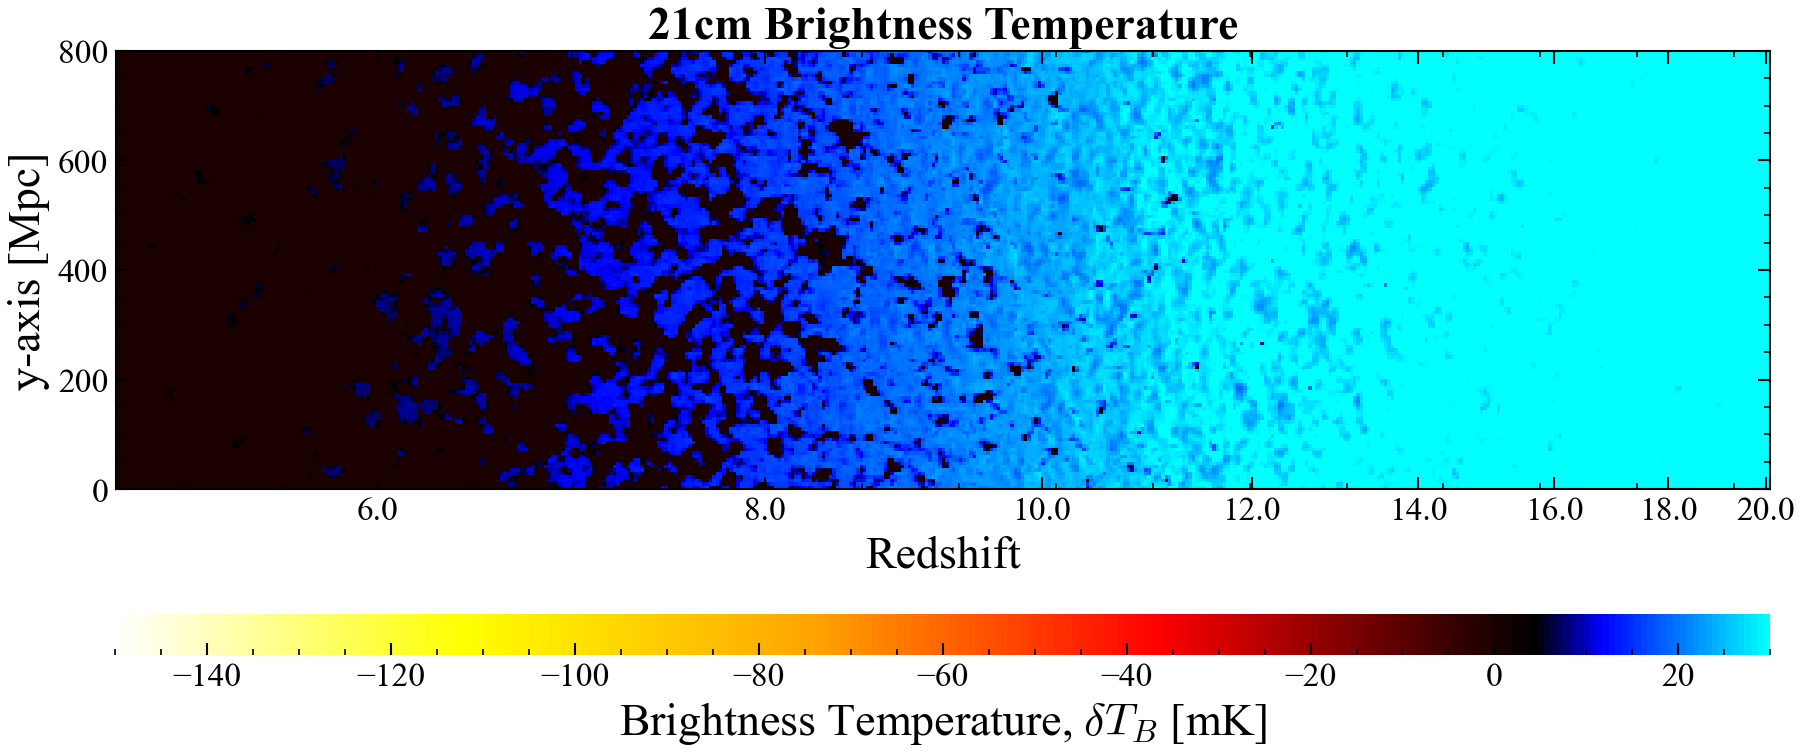

Saved: density_lightcone


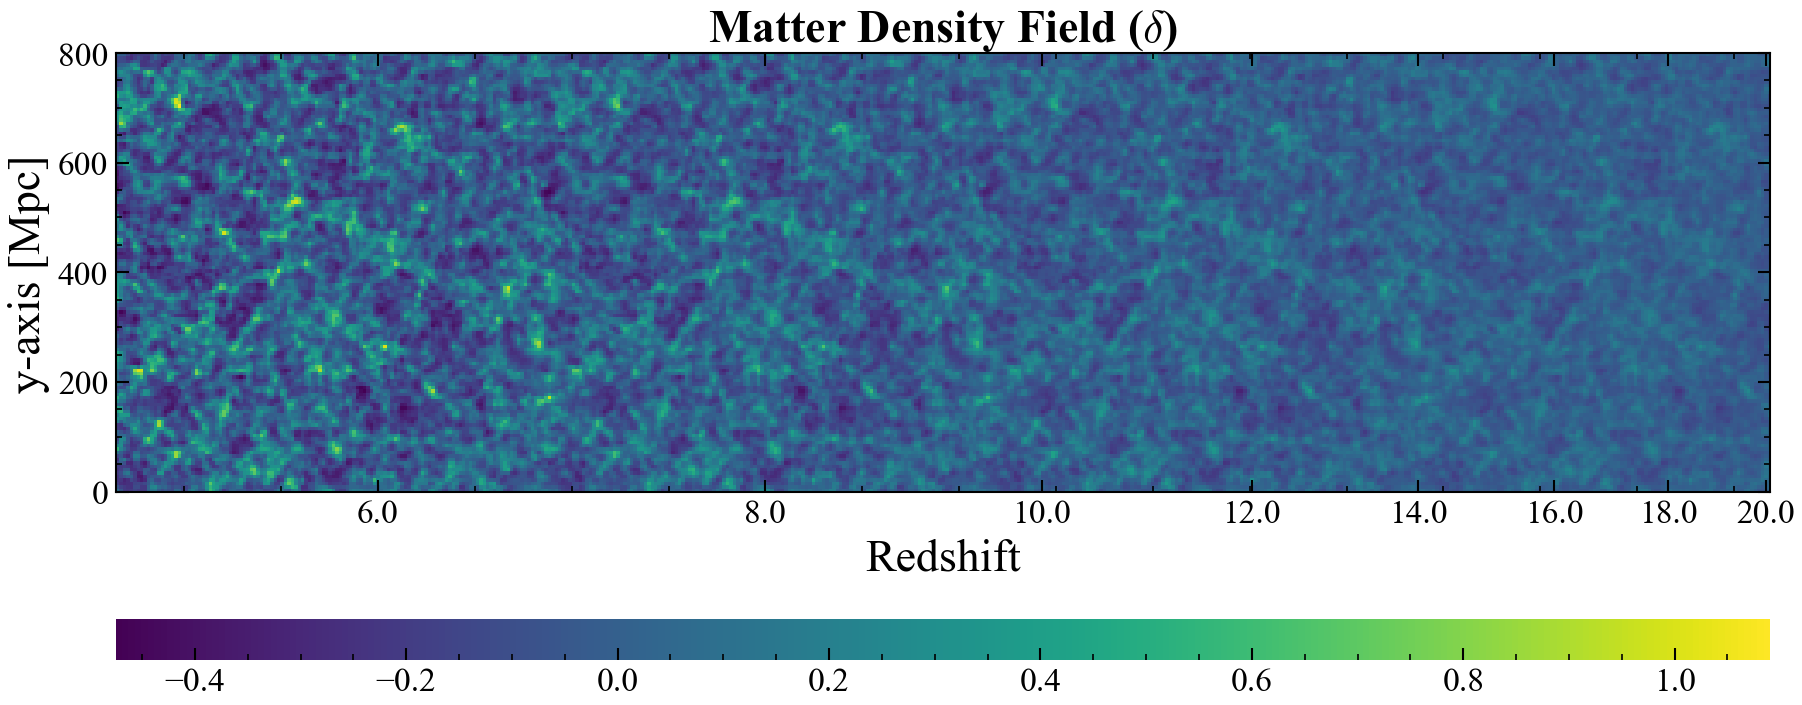

Saved: velocity_z_lightcone


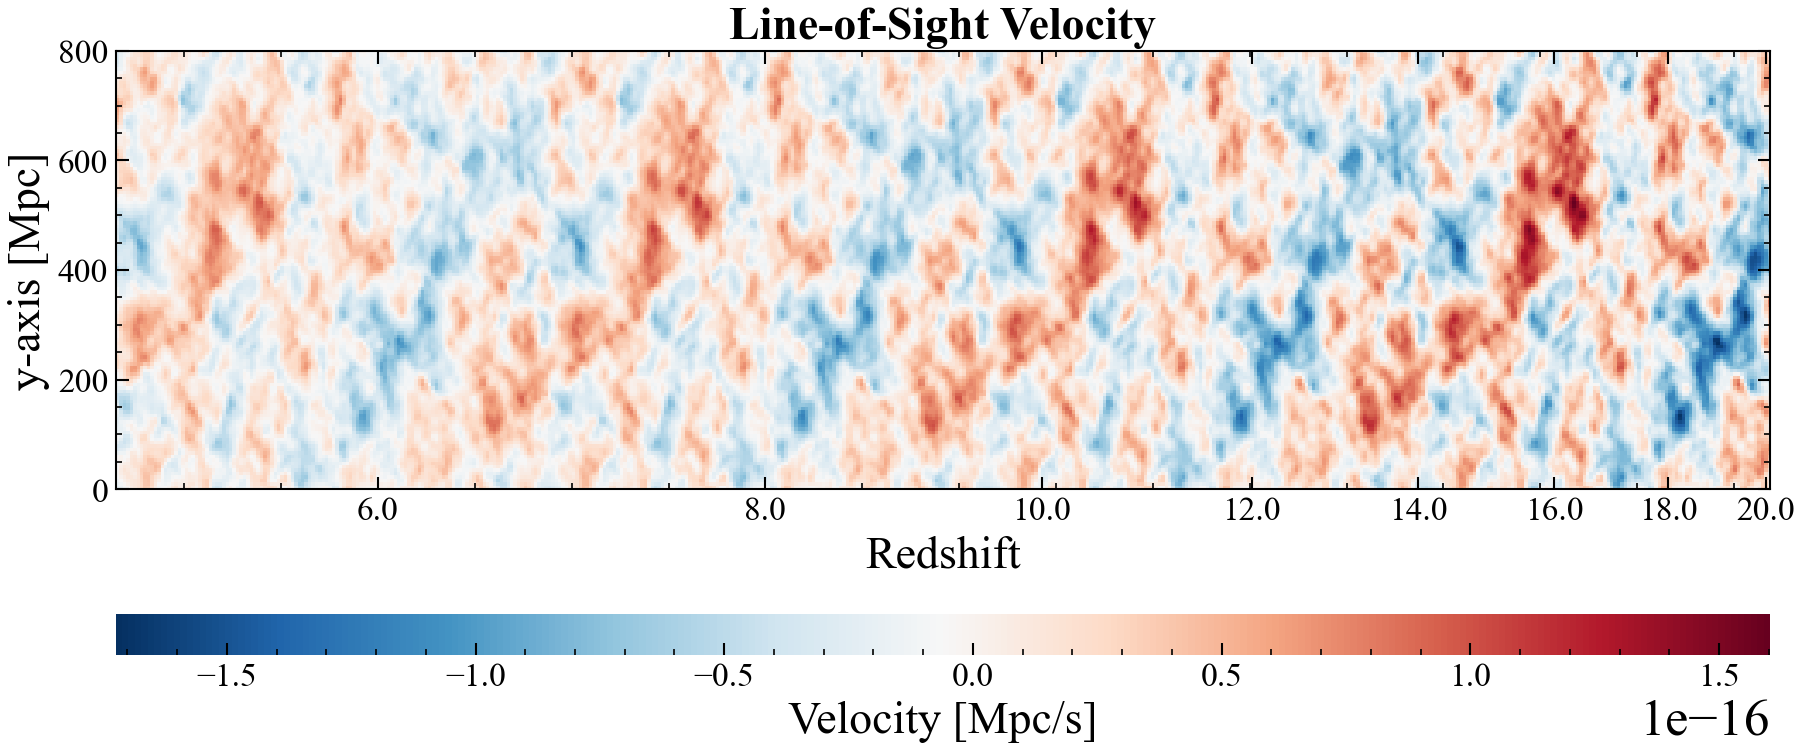

Saved: xHI_lightcone


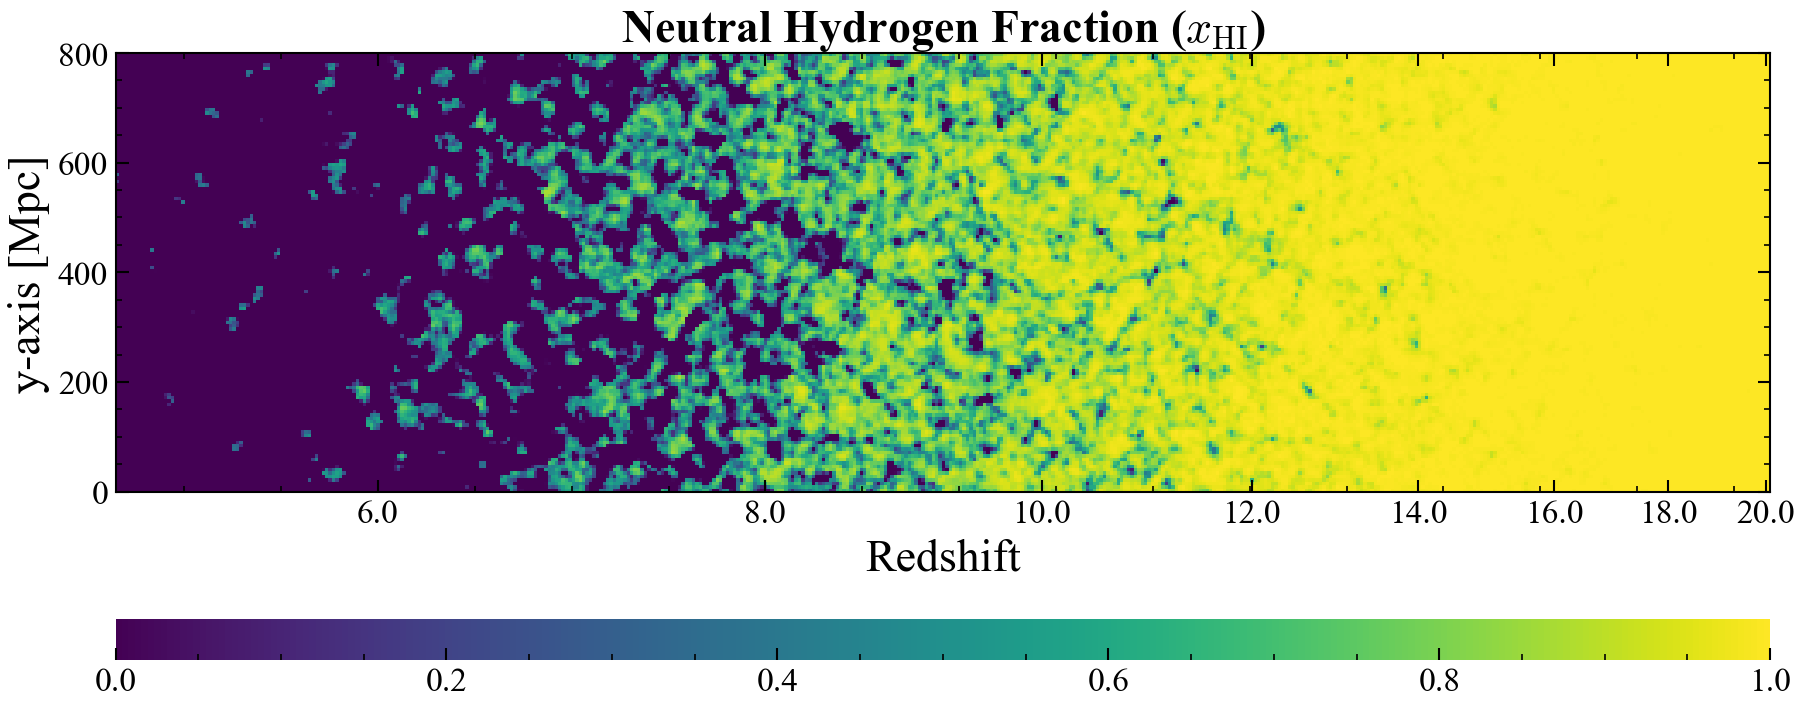


=== ALL PLOTS SAVED ===
Location: /home/swanith/Desktop/Project2/Plots/Lightconer_v3/31DEC25_lightcone_plots_v3
Files created:
  - brightness_temp_lightcone.pdf
  - brightness_temp_lightcone.png
  - density_lightcone.pdf
  - density_lightcone.png
  - ds_vs_z.pdf
  - ds_vs_z.png
  - dtau_vs_z.pdf
  - dtau_vs_z.png
  - kSZ_Cl_corrected.pdf
  - kSZ_Cl_corrected.png
  - kSZ_Dl_corrected.pdf
  - kSZ_Dl_corrected.png
  - kSZ_Dl_muK2.pdf
  - kSZ_Dl_muK2.png
  - kSZ_Dl_muK2_with_observations.pdf
  - kSZ_Dl_muK2_with_observations.png
  - kSZ_Pk.pdf
  - kSZ_Pk.png
  - kSZ_integrand_no_visibility.pdf
  - kSZ_integrand_no_visibility.png
  - kSZ_integrand_with_visibility.pdf
  - kSZ_integrand_with_visibility.png
  - kSZ_map_histogram.pdf
  - kSZ_map_histogram.png
  - kSZ_map_z5.pdf
  - kSZ_map_z5.png
  - s_vs_z.pdf
  - s_vs_z.png
  - tau_vs_z.pdf
  - tau_vs_z.png
  - velocity_z_lightcone.pdf
  - velocity_z_lightcone.png
  - xHI_lightcone.pdf
  - xHI_lightcone.png
  - xe_vs_z.pdf
  - xe_vs_z.png


In [62]:
# =============================================================================
# CELL 2: Run Lightcone Simulation
# Using defaults for cosmo/astro/flags - only override if needed
# =============================================================================

print("\n=== RUNNING LIGHTCONE ===")
print(f"Redshift range: z = {z_min} → {z_max}")
print(f"Box size: {user_params.BOX_LEN} Mpc")
print(f"Resolution: {user_params.HII_DIM}³ cells")

lightcone = p21c.run_lightcone(
    redshift=z_min,                           # Final redshift
    max_redshift=z_max,                       # Starting redshift
    lightcone_quantities=('brightness_temp', 'density', 'xH_box', 'velocity'),
    #global_quantities=('xH_box'),
    user_params=user_params,
    random_seed=37,                           # For reproducibility
    direc='_cache'                            # Cache directory
)

print("\nLightcone simulation complete!")
print(f"Lightcone shape: {lightcone.brightness_temp.shape}")
print(f"Number of redshift slices: {len(lightcone.lightcone_redshifts)}")


# =============================================================================
# CELL 2a: Inspect Lightcone Structure
# What fields are available and their shapes
# =============================================================================

print("\n=== LIGHTCONE CONTENTS ===")
print(f"Redshift axis: z ∈ [{lightcone.lightcone_redshifts.min():.2f}, "
      f"{lightcone.lightcone_redshifts.max():.2f}]")
print(f"Comoving distance axis: r ∈ [{lightcone.lightcone_distances.min():.1f}, "
      f"{lightcone.lightcone_distances.max():.1f}] Mpc")

print("\nAvailable fields:")
for field in ['brightness_temp', 'density', 'xH_box', 'velocity']:
    if hasattr(lightcone, field):
        data = getattr(lightcone, field)
        print(f"  {field:20s} -> shape {data.shape}, dtype {data.dtype}")


# =============================================================================
# CELL 2b: Extract Redshift and Distance Axes
# Trim to the requested redshift range if needed
# =============================================================================

# Full axes from lightcone
red_axis = lightcone.lightcone_redshifts      # Redshift per slice
pos_axis = lightcone.lightcone_distances      # Comoving distance [Mpc]

# Trim to z <= z_max (in case simulation went slightly beyond)
ind_z = np.where(red_axis <= z_max)[0]
red_axis = red_axis[ind_z]
pos_axis = pos_axis[ind_z]

print(f"\nTrimmed axes:")
print(f"  Redshift: {len(red_axis)} slices from z={red_axis.min():.2f} to z={red_axis.max():.2f}")
print(f"  Distance: {pos_axis.min():.1f} to {pos_axis.max():.1f} Mpc")


# =============================================================================
# CELL 2c1: PLOT 1 - Brightness Temperature (21cm signal)
# Default quantity for 21cm observations
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(
    lightcone, 
    'brightness_temp',  # 21cm brightness temperature [mK]
    ax=ax, 
    fig=fig
)
# Lightcone-specific typography overrides

# Axis tick labels
ax.tick_params(
    axis='both',
    which='major',
    labelsize=16
)

# Axis labels (x/y titles)
ax.xaxis.label.set_size(22)
ax.yaxis.label.set_size(22)

# Colorbar ticks and label
for cax in fig.axes:
    if cax is not ax:  # this is the colorbar axis
        cax.tick_params(labelsize=16)
        cax.xaxis.label.set_size(22)  # colorbar label size


plot_name = "brightness_temp_lightcone"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title="21cm Brightness Temperature"
)

print(f"Saved: {plot_name}")
plt.show()



# =============================================================================
# CELL 2c2: PLOT 2 - Density Field
# Matter overdensity (δ)
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(
    lightcone, 
    'density',          # Density field (δ)
    ax=ax, 
    fig=fig
)

# Lightcone-specific typography overrides

# Axis tick labels
ax.tick_params(
    axis='both',
    which='major',
    labelsize=16
)

# Axis labels (x/y titles)
ax.xaxis.label.set_size(22)
ax.yaxis.label.set_size(22)

# Colorbar ticks and label
for cax in fig.axes:
    if cax is not ax:  # this is the colorbar axis
        cax.tick_params(labelsize=16)
        cax.xaxis.label.set_size(22)  # colorbar label size



plot_name = "density_lightcone"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"Matter Density Field ($\delta$)"
)

print(f"Saved: {plot_name}")
plt.show()


# =============================================================================
# CELL 2c3: PLOT 3 - Line-of-Sight Velocity
# Peculiar velocity along the z-axis
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(
    lightcone, 
    'velocity',         # Velocity along line-of-sight [comoving km/s]
    ax=ax, 
    fig=fig
)

# Change colormap after the plot is created
im = ax.images[0]  # Get the image object
im.set_cmap('RdBu_r')  # Set new colormap

#ax.set_title('LOS-Velocity (Mpc/s)', fontsize=14, fontweight='bold')

# Add horizontal label to colorbar (below it)
cbar = fig.get_axes()[-1]  # Get the colorbar axis
cbar.set_xlabel('Velocity [Mpc/s]')

# Lightcone-specific typography overrides

# Axis tick labels
ax.tick_params(
    axis='both',
    which='major',
    labelsize=16
)

# Axis labels (x/y titles)
ax.xaxis.label.set_size(22)
ax.yaxis.label.set_size(22)

# Colorbar ticks and label
for cax in fig.axes:
    if cax is not ax:  # this is the colorbar axis
        cax.tick_params(labelsize=16)
        cax.xaxis.label.set_size(22)  # colorbar label size



# Save the plot
plot_name = "velocity_z_lightcone"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title="Line-of-Sight Velocity"
)

print(f"Saved: {plot_name}")
plt.show()


# =============================================================================
# CELL 2c4: PLOT 4 - Neutral Fraction
# Fraction of neutral hydrogen (xHI)
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(
    lightcone, 
    'xH_box',           # Neutral hydrogen fraction
    ax=ax, 
    fig=fig
)
# Save PDF without title

# Lightcone-specific typography overrides

# Axis tick labels
ax.tick_params(
    axis='both',
    which='major',
    labelsize=16
)

# Axis labels (x/y titles)
ax.xaxis.label.set_size(22)
ax.yaxis.label.set_size(22)

# Colorbar ticks and label
for cax in fig.axes:
    if cax is not ax:  # this is the colorbar axis
        cax.tick_params(labelsize=16)
        cax.xaxis.label.set_size(22)  # colorbar label size



plot_name = "xHI_lightcone"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"Neutral Hydrogen Fraction ($x_{\mathrm{HI}}$)"
)

print(f"Saved: {plot_name}")
plt.show()


# =============================================================================
# Summary
# =============================================================================
print(f"\n=== ALL PLOTS SAVED ===")
print(f"Location: {os.path.abspath(plot_dir)}")
print(f"Files created:")
for fname in sorted(os.listdir(plot_dir)):
    print(f"  - {fname}")

In [35]:
# =============================================================================
# CELL 3: Extract 3D Fields (if needed for further analysis)
# Trimmed to the redshift range of interest
# =============================================================================

# Extract fields with proper indexing
brightness_temp = lightcone.brightness_temp[:, :, ind_z]  # [mK]
density_field   = 1+ lightcone.density[:, :, ind_z]          # 1 + δ
neutral_frac    = lightcone.xH_box[:, :, ind_z]           # xHI
velocity_los    = 1e17*lightcone.velocity[:, :, ind_z]         # [comoving km/s]

print("\n=== EXTRACTED 3D FIELDS ===")
print(f"Brightness temperature: {brightness_temp.shape}")
print(f"Density field:          {density_field.shape}")
print(f"Neutral fraction:       {neutral_frac.shape}")


# =============================================================================
# CELL 3a: Summary Statistics (Optional)
# Quick overview of the simulation results
# =============================================================================

print("\n=== SUMMARY STATISTICS ===")
print(f"Brightness temperature: min={brightness_temp.min():.1f} mK, "
      f"max={brightness_temp.max():.1f} mK, mean={brightness_temp.mean():.1f} mK")
print(f"Neutral fraction:       min={neutral_frac.min():.3f}, "
      f"max={neutral_frac.max():.3f}, mean={neutral_frac.mean():.3f}")
print(f"Density (1+δ):          min={density_field.min():.3f}, "
      f"max={density_field.max():.3f}, mean={density_field.mean():.3f}")
print(f"Velocity_z (1e-17 Mpc/s):          min={velocity_los.min():.3f}, "
      f"max={velocity_los.max():.3f}, mean={velocity_los.mean():.3f}")

# =============================================================================
# NOTES ON CUSTOMIZATION:
# 
# If you want to change cosmology/astrophysics from defaults, add:
#
#   cosmo_params = p21c.CosmoParams(
#       SIGMA_8=0.81,      # Matter power spectrum normalization
#       hlittle=0.68,      # Hubble parameter h
#       OMm=0.31,          # Total matter density
#       OMb=0.049,         # Baryon density
#       POWER_INDEX=0.965  # Primordial spectral index n_s
#   )
#
#   astro_params = p21c.AstroParams(
#       HII_EFF_FACTOR=30.0,  # Ionization efficiency
#       R_BUBBLE_MAX=30.0,    # Maximum bubble size [Mpc]
#       L_X=1e40              # X-ray luminosity per SFR
#   )
#
#   flag_options = p21c.FlagOptions(
#       USE_TS_FLUCT=True     # Include spin temperature fluctuations
#   )
#
# Then pass them to run_lightcone():
#   lightcone = p21c.run_lightcone(
#       ...,
#       cosmo_params=cosmo_params,
#       astro_params=astro_params,
#       flag_options=flag_options
#   )
# =============================================================================


=== EXTRACTED 3D FIELDS ===
Brightness temperature: (128, 128, 482)
Density field:          (128, 128, 482)
Neutral fraction:       (128, 128, 482)

=== SUMMARY STATISTICS ===
Brightness temperature: min=0.0 mK, max=58.8 mK, mean=18.0 mK
Neutral fraction:       min=0.000, max=1.000, mean=0.589
Density (1+δ):          min=0.412, max=3.230, mean=1.000
Velocity_z (1e-17 Mpc/s):          min=-23.159, max=23.457, mean=-0.044



=== INTERPOLATED IONIZATION FRACTION ===
x_e range: [0.0000, 0.9992]

=== GEOMETRIC QUANTITIES ===
s range: [7946.5 Mpc, 10952.7 Mpc] Mpc
ds: mean = 6.250 Mpc Mpc, std = 0.000 Mpc Mpc
Number of slices: 482

=== OPTICAL DEPTH ===
dτ range: [7.458399e-08 Mpc, 1.605852e-04 Mpc]
Total τ: 0.040152 Mpc
Integrated from z = 5.00 → 19.95
Saved: s_vs_z


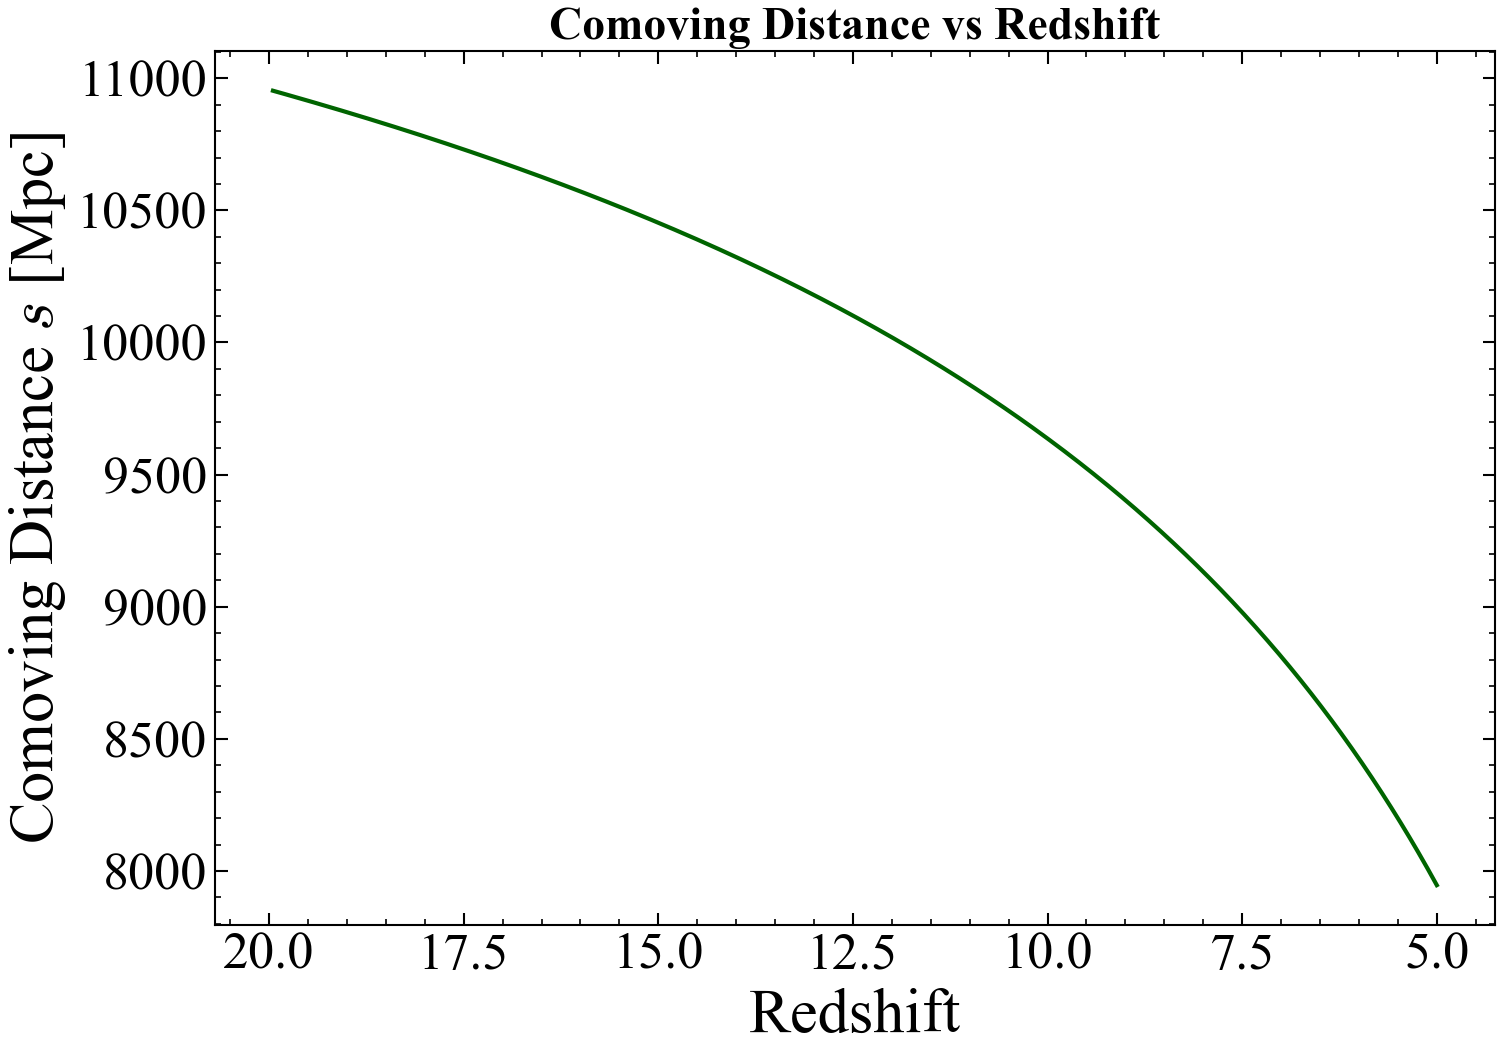

Saved: ds_vs_z


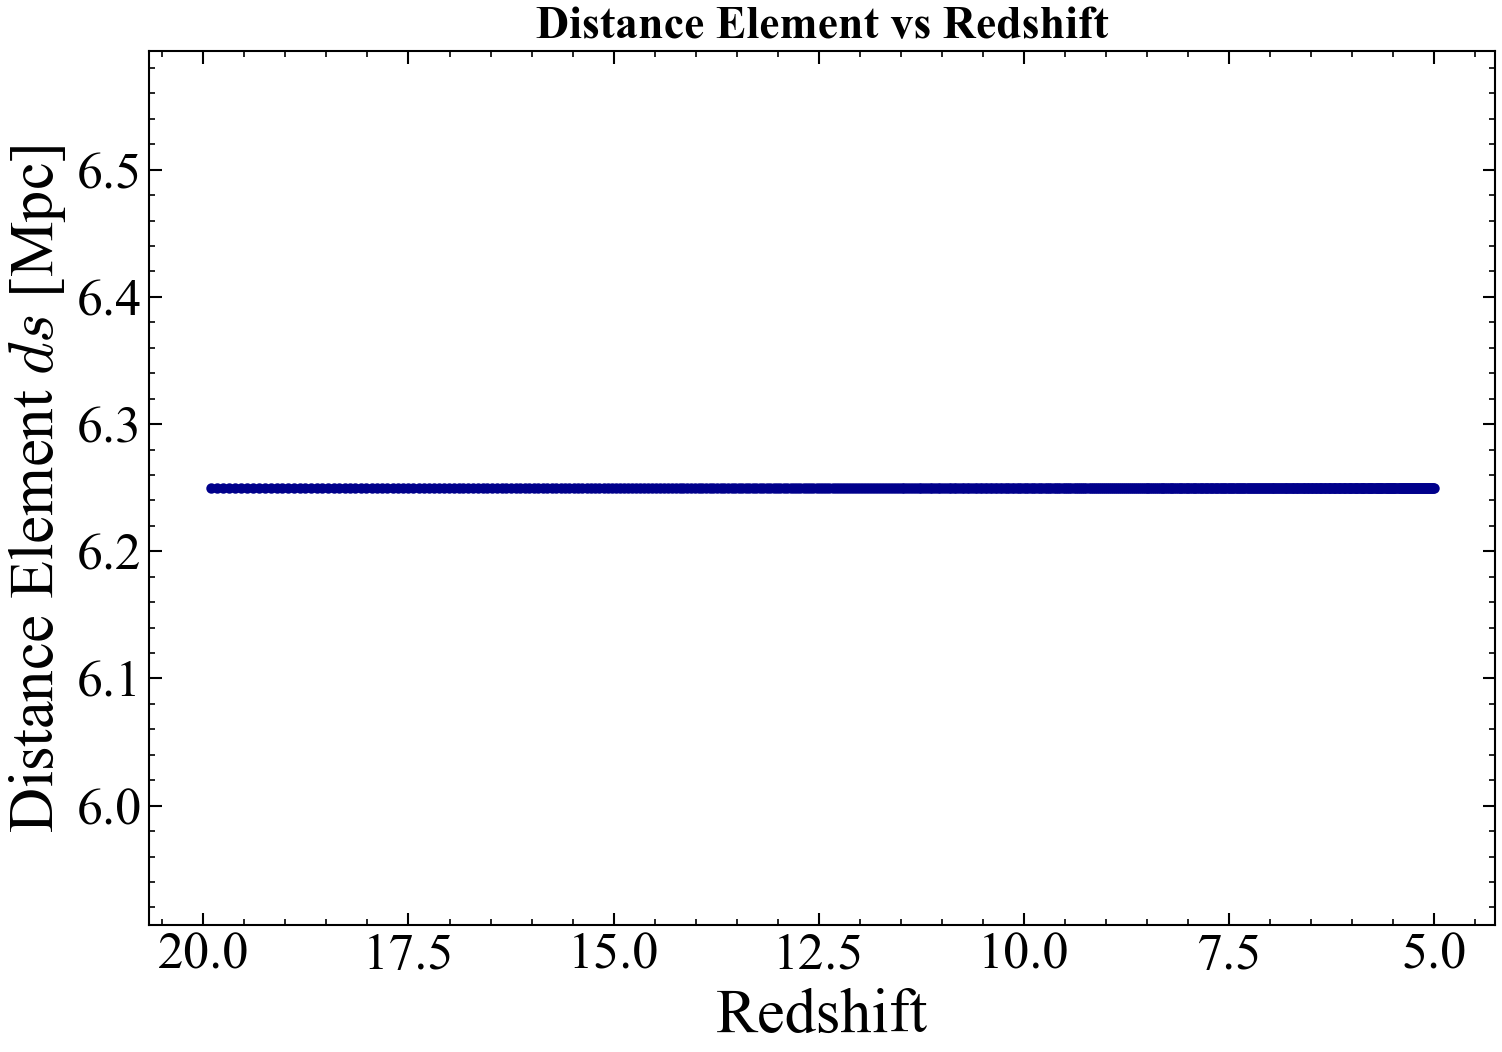

Saved: xe_vs_z


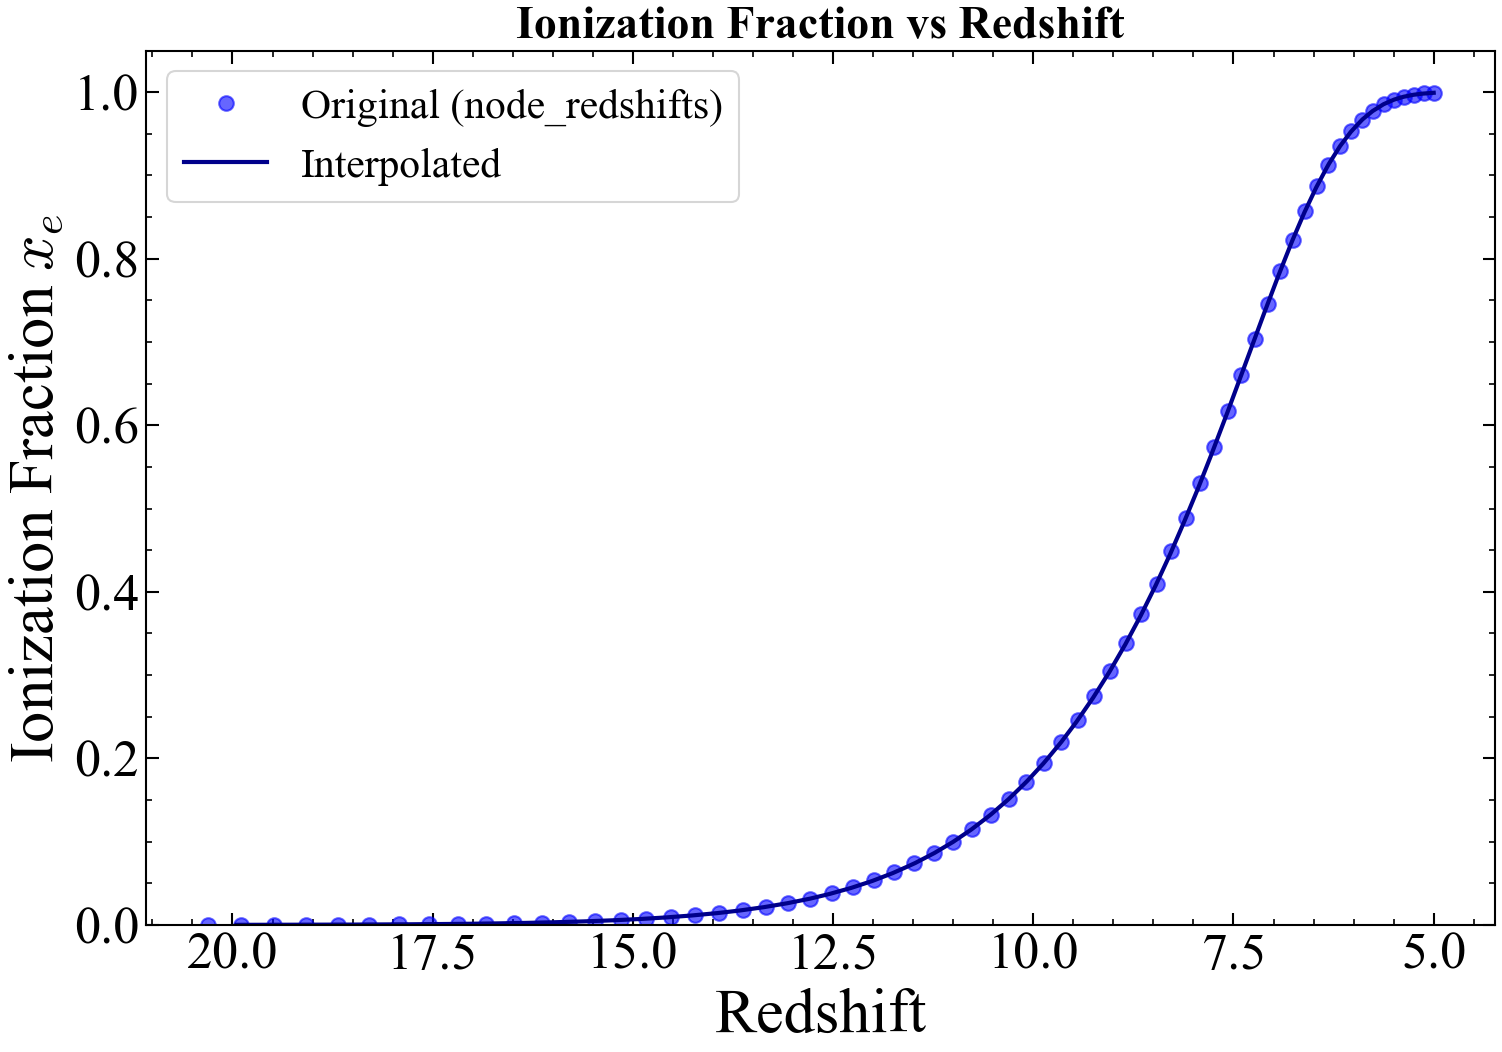

Saved: dtau_vs_z


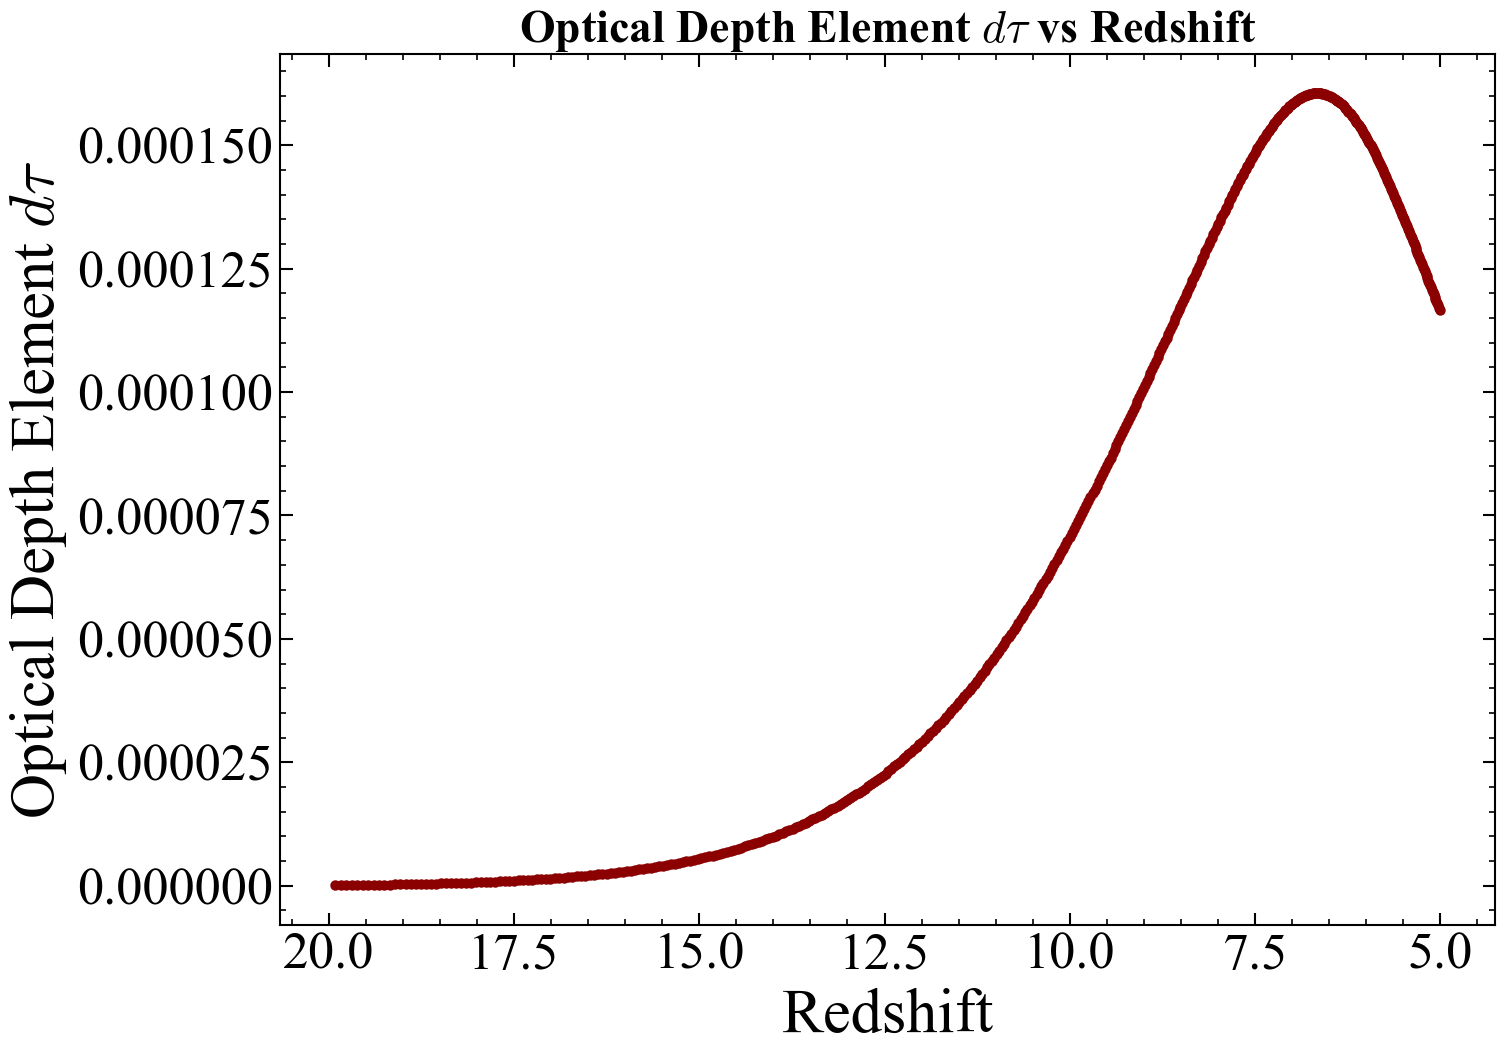

Saved: tau_vs_z


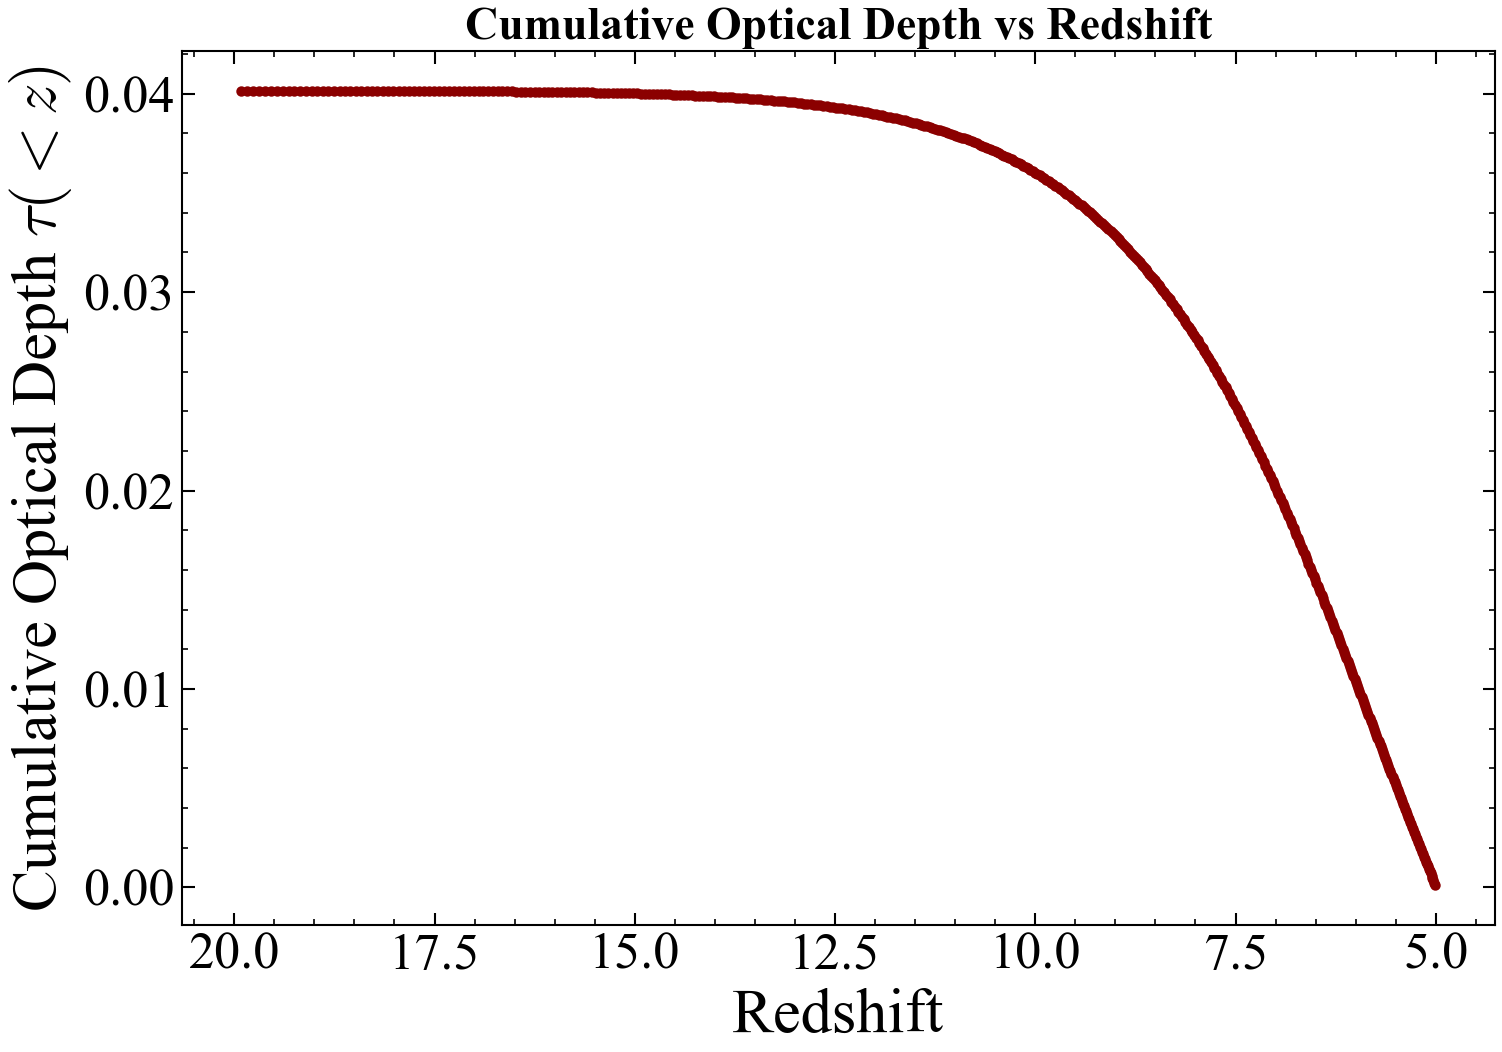


SUMMARY OF CALCULATIONS
Redshift range:           5.00 → 19.95
Comoving distance:        7946.5 Mpc → 10952.7 Mpc Mpc
Mean distance element:    6.250 Mpc Mpc
Ionization fraction:      0.0000 → 0.9992
Total optical depth:      τ = 0.040152 Mpc
Number of data points:    482


In [46]:
# =============================================================================
# COMPLETE CELL 4: Calculate and Plot s, ds, x_e, dτ, τ vs z
# Using interpolated x_e onto lightcone redshifts
# =============================================================================

# =============================================================================
# Step 1: Interpolate x_e onto lightcone redshifts
# =============================================================================

# Reverse node arrays to match lightcone order (low z → high z)
z_nodes_sorted = lightcone.node_redshifts[::-1]      # 5.0 → 20.3
xHI_nodes_sorted = lightcone.global_xH[::-1]
x_e_nodes_sorted = 1.0 - xHI_nodes_sorted

# Interpolate x_e onto lightcone redshift grid
x_e_interp = np.interp(red_axis, z_nodes_sorted, x_e_nodes_sorted)

print(f"\n=== INTERPOLATED IONIZATION FRACTION ===")
print(f"x_e range: [{x_e_interp.min():.4f}, {x_e_interp.max():.4f}]")

# =============================================================================
# Step 2: Extract/Calculate geometric quantities
# =============================================================================

# Comoving distance (already available)
s = pos_axis  # Comoving distance [Mpc]

# Distance element
ds = np.diff(s)  # [Mpc], length 963

# Midpoint values for integration
z_mid = 0.5 * (red_axis[:-1] + red_axis[1:])
x_e_mid = 0.5 * (x_e_interp[:-1] + x_e_interp[1:])

print(f"\n=== GEOMETRIC QUANTITIES ===")
print(f"s range: [{s.min():.1f}, {s.max():.1f}] Mpc")
print(f"ds: mean = {ds.mean():.3f} Mpc, std = {ds.std():.3f} Mpc")
print(f"Number of slices: {len(red_axis)}")

# =============================================================================
# Step 3: Calculate dτ and τ
# =============================================================================
# Physical constants for optical depth calculation
c_km_s = 2.998e5                    # Speed of light [km/s]
h = 0.6766                          # Hubble parameter (from default cosmology)
H0 = 100 * h                        # Hubble constant [km/s/Mpc]
Omega_b = 0.04897468161869667       # Baryon density (from default cosmology)
Omega_m = 0.30964144154550644       # Matter density (from default cosmology)

# Critical density of the universe [protons/cm^3]
rho_crit_p_cm3 = 1.88e-29 * h**2 / (1.67e-24)  # Convert to protons/cm^3
n_H0_cm3 = Omega_b * rho_crit_p_cm3             # Mean hydrogen number density [cm^-3]

# Thomson scattering cross section
sigma_T_cm2 = 6.65e-25              # [cm^2]

# Convert to Mpc units
cm_per_Mpc = 3.086e24
n_e0_Mpc3 = n_H0_cm3 * cm_per_Mpc**3
sigma_T_Mpc2 = sigma_T_cm2 / cm_per_Mpc**2

# Prefactor for dτ calculation
prefactor = n_e0_Mpc3 * sigma_T_Mpc2  # [Mpc^-1]
# Calculate dτ
dtau = prefactor * x_e_mid * (1.0 + z_mid)**2 * ds

# Cumulative optical depth
tau = np.cumsum(dtau)
tau_total = tau[-1]

print(f"\n=== OPTICAL DEPTH ===")
print(f"dτ range: [{dtau.min():.6e}, {dtau.max():.6e}]")
print(f"Total τ: {tau_total:.6f}")
print(f"Integrated from z = {red_axis.min():.2f} → {red_axis.max():.2f}")

# =============================================================================
# PLOT 1: Comoving Distance s vs z
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
ax.plot(red_axis, s, '-', linewidth=2, color='darkgreen')
ax.set_xlabel('Redshift')
ax.set_ylabel(r'Comoving Distance $s$ [Mpc]')
ax.invert_xaxis()

plot_name = "s_vs_z"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title="Comoving Distance vs Redshift"
)

print(f"Saved: {plot_name}")
plt.show()


# =============================================================================
# PLOT 2: Distance Element ds vs z
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)

ax.plot(
    z_mid,
    ds,
    'o-',
    linewidth=2,
    markersize=4,
    color='darkblue'
)

ax.set_xlabel('Redshift')
ax.set_ylabel(r'Distance Element $ds$ [Mpc]')
ax.invert_xaxis()

plot_name = "ds_vs_z"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title="Distance Element vs Redshift"
)

print(f"Saved: {plot_name}")
plt.show()

# =============================================================================
# PLOT 3: Ionization Fraction x_e vs z
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)

ax.plot(
    z_nodes_sorted,
    x_e_nodes_sorted,
    'o',
    markersize=7,
    label='Original (node_redshifts)',
    color='blue',
    alpha=0.6
)

ax.plot(
    red_axis,
    x_e_interp,
    '-',
    linewidth=2,
    label='Interpolated',
    color='darkblue'
)

ax.set_xlabel('Redshift')
ax.set_ylabel(r'Ionization Fraction $x_e$')
ax.set_ylim(0.0, 1.05)
ax.legend(loc='best')
ax.invert_xaxis()
plot_name = "xe_vs_z"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title="Ionization Fraction vs Redshift"
)

print(f"Saved: {plot_name}")
plt.show()


# =============================================================================
# PLOT: Optical Depth Element dτ vs z
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)

ax.plot(
    z_mid,
    dtau,
    'o-',
    linewidth=2,
    markersize=4,
    color='darkred'
)

ax.set_xlabel('Redshift')
ax.set_ylabel(r'Optical Depth Element $d\tau$')
ax.invert_xaxis()

plot_name = "dtau_vs_z"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"Optical Depth Element $d\tau$ vs Redshift"
)

print(f"Saved: {plot_name}")
plt.show()


# =============================================================================
# PLOT: Cumulative Optical Depth τ vs z
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)

ax.plot(
    z_mid,
    tau,
    'o-',
    linewidth=2.5,
    markersize=4,
    color='darkred'
)

ax.set_xlabel('Redshift')
ax.set_ylabel(r'Cumulative Optical Depth $\tau(<z)$')
ax.invert_xaxis()

plot_name = "tau_vs_z"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title="Cumulative Optical Depth vs Redshift"
)

print(f"Saved: {plot_name}")
plt.show()


# =============================================================================
# Summary
# =============================================================================

print(f"\n{'='*60}")
print(f"SUMMARY OF CALCULATIONS")
print(f"{'='*60}")
print(f"Redshift range:           {red_axis.min():.2f} → {red_axis.max():.2f}")
print(f"Comoving distance:        {s.min():.1f} → {s.max():.1f} Mpc")
print(f"Mean distance element:    {ds.mean():.3f} Mpc")
print(f"Ionization fraction:      {x_e_interp.min():.4f} → {x_e_interp.max():.4f}")
print(f"Total optical depth:      τ = {tau_total:.6f}")
print(f"Number of data points:    {len(red_axis)}")
print(f"{'='*60}")

Speed of light: c = 9.715612e-15 Mpc/s

=== OPTICAL DEPTH AT LIGHTCONE REDSHIFTS ===
τ range: [0.000000, 0.040152]
τ is dimensionless: <class 'numpy.ndarray'>

=== VISIBILITY FUNCTION ===
e^(-τ) range: [0.960644, 1.000000]

=== kSZ INTEGRAND (no visibility) STATISTICS ===
  Mean: 1.6107e-06
  Std:  2.1939e-03
  Min:  -2.4088e-02
  Max:  2.7248e-02
  RMS:  2.1939e-03

=== kSZ INTEGRAND (with visibility) STATISTICS ===
  Mean: 1.6627e-06
  Std:  2.1593e-03
  Min:  -2.3798e-02
  Max:  2.7095e-02
  RMS:  2.1593e-03
Saved: kSZ_integrand_no_visibility


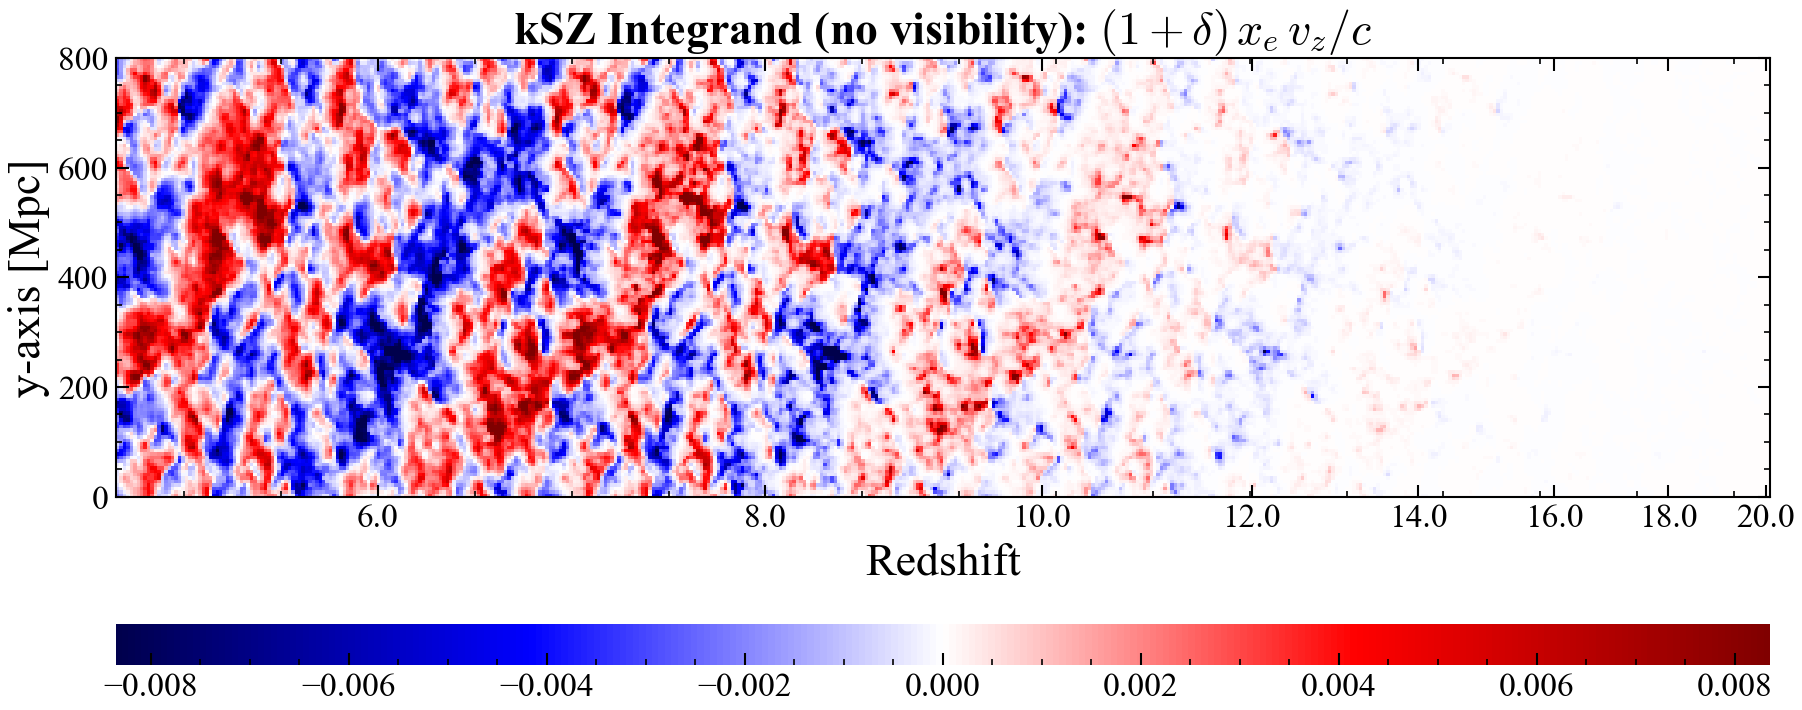

Saved: kSZ_integrand_with_visibility


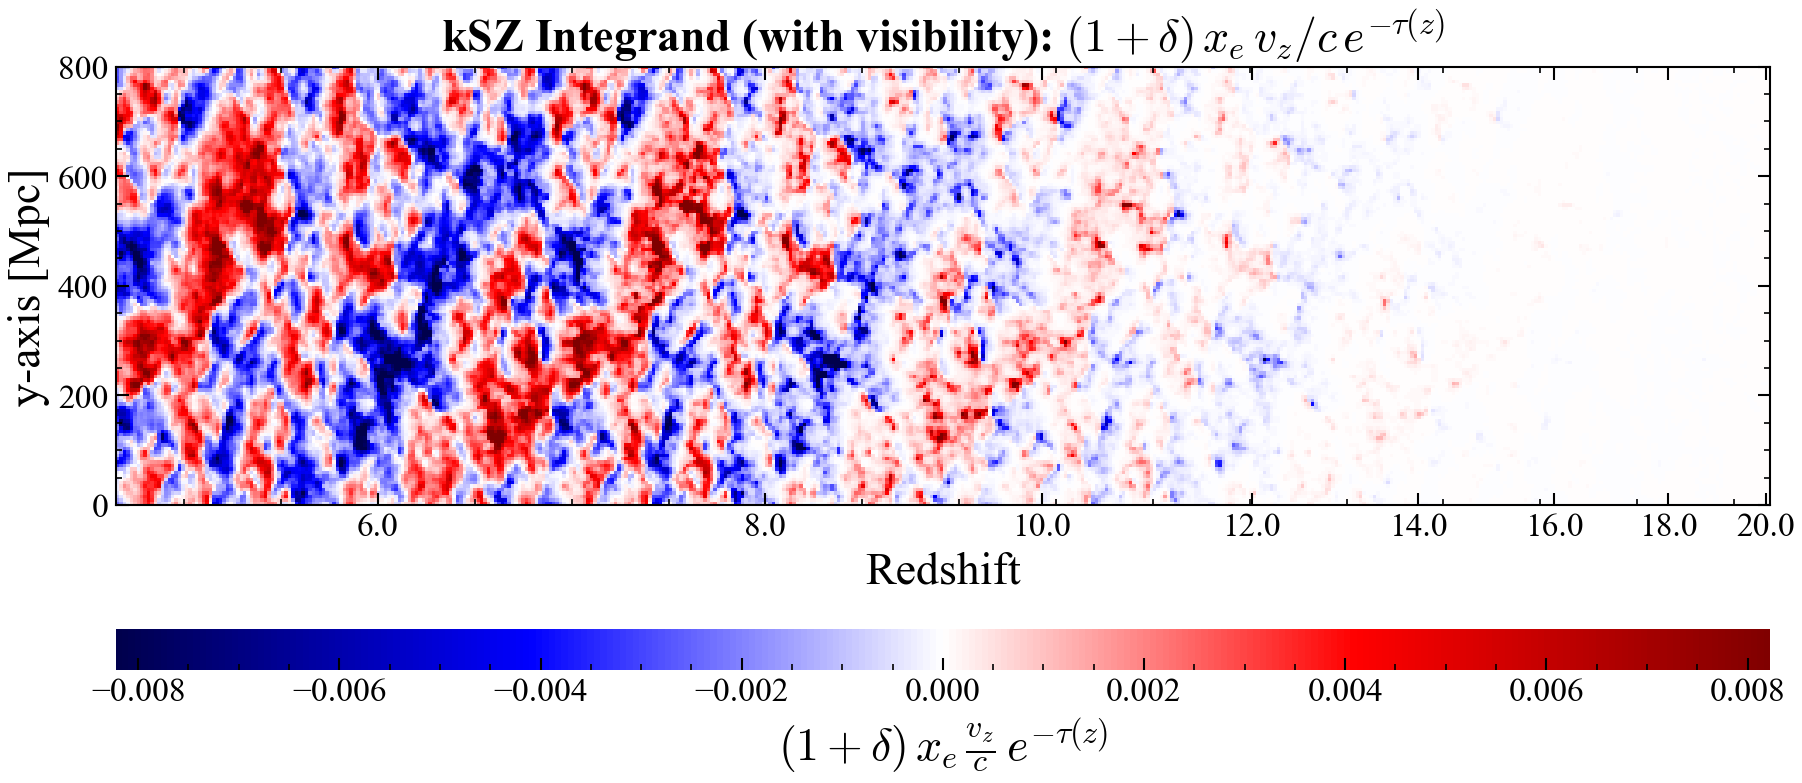


kSZ INTEGRAND SUMMARY
Effect of visibility function:
  RMS without e^(-τ): 2.1939e-03
  RMS with e^(-τ):    2.1593e-03
  Suppression factor: 0.9842


In [65]:
# =============================================================================
# CELL 5: Compute kSZ Integrand with Visibility Function
# kSZ integrand = (1 + δ) × x_e × v_z / c × e^(-τ(z))
# =============================================================================

# Extract fields (already trimmed to ind_z)
density_1plus = 1 + lightcone.density[:, :, ind_z]  # 1 + δ
x_e_3D = 1 - lightcone.xH_box[:, :, ind_z]          # Ionized fraction (3D field)
v_los_Mpc_s = lightcone.velocity[:, :, ind_z]    # Velocity in Mpc/s

# Speed of light in Mpc/s
c_Mpc_s = 299792.458 / 3.08567758e19  # Mpc/s
print(f"Speed of light: c = {c_Mpc_s:.6e} Mpc/s")

# =============================================================================
# Interpolate τ(z) onto lightcone redshifts
# =============================================================================

# Ensure tau is dimensionless (strip any units)
tau_dimensionless = np.asarray(tau, dtype=float)

# tau is defined at z_mid (midpoints), need to interpolate to red_axis
# Extend tau to match red_axis length by prepending 0 (at lowest z)
tau_extended = np.concatenate([[0], tau_dimensionless])

# Interpolate tau onto red_axis (trimmed)
tau_at_lightcone = np.interp(red_axis, 
                              np.concatenate([[red_axis[0]], z_mid]), 
                              tau_extended)

print(f"\n=== OPTICAL DEPTH AT LIGHTCONE REDSHIFTS ===")
print(f"τ range: [{tau_at_lightcone.min():.6f}, {tau_at_lightcone.max():.6f}]")
print(f"τ is dimensionless: {type(tau_at_lightcone)}")

# Visibility function e^(-τ)
visibility = np.exp(-tau_at_lightcone)

print(f"\n=== VISIBILITY FUNCTION ===")
print(f"e^(-τ) range: [{visibility.min():.6f}, {visibility.max():.6f}]")

# Broadcast visibility to 3D for multiplication with lightcone fields
# visibility shape: (964,) -> need to reshape to (1, 1, 964) for broadcasting
visibility_3D = visibility[None, None, :]  # Shape (1, 1, 964)

# =============================================================================
# Compute kSZ integrand WITHOUT visibility (for comparison)
# =============================================================================

kSZ_integrand_no_vis = density_1plus * x_e_3D * v_los_Mpc_s / c_Mpc_s

print(f"\n=== kSZ INTEGRAND (no visibility) STATISTICS ===")
print(f"  Mean: {kSZ_integrand_no_vis.mean():.4e}")
print(f"  Std:  {kSZ_integrand_no_vis.std():.4e}")
print(f"  Min:  {kSZ_integrand_no_vis.min():.4e}")
print(f"  Max:  {kSZ_integrand_no_vis.max():.4e}")
print(f"  RMS:  {np.sqrt(np.mean(kSZ_integrand_no_vis**2)):.4e}")

# =============================================================================
# Compute kSZ integrand WITH visibility function
# =============================================================================

kSZ_integrand_with_vis = density_1plus * x_e_3D * v_los_Mpc_s / c_Mpc_s * visibility_3D

print(f"\n=== kSZ INTEGRAND (with visibility) STATISTICS ===")
print(f"  Mean: {kSZ_integrand_with_vis.mean():.4e}")
print(f"  Std:  {kSZ_integrand_with_vis.std():.4e}")
print(f"  Min:  {kSZ_integrand_with_vis.min():.4e}")
print(f"  Max:  {kSZ_integrand_with_vis.max():.4e}")
print(f"  RMS:  {np.sqrt(np.mean(kSZ_integrand_with_vis**2)):.4e}")

# Add to lightcone object for easy access
lightcone.kSZ_integrand_no_vis = kSZ_integrand_no_vis
lightcone.kSZ_integrand = kSZ_integrand_with_vis  # This is the physical one
lightcone.visibility = visibility_3D

# =============================================================================
# PLOT 1: kSZ Integrand WITHOUT Visibility
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(lightcone, 'kSZ_integrand_no_vis', ax=ax, fig=fig)

# Change colormap to seismic (better contrast for data centered near zero)
im = ax.images[0]
im.set_cmap('seismic')

# Set symmetric color limits around zero for better visualization
vmax = np.percentile(np.abs(kSZ_integrand_no_vis), 99)  # Use 99th percentile to avoid outliers
im.set_clim(-vmax, vmax)

# Add colorbar label
cbar = fig.get_axes()[-1]
# Lightcone-specific typography overrides

# Axis tick labels
ax.tick_params(
    axis='both',
    which='major',
    labelsize=16
)

# Axis labels (x/y titles)
ax.xaxis.label.set_size(22)
ax.yaxis.label.set_size(22)

# Colorbar ticks and label
for cax in fig.axes:
    if cax is not ax:  # this is the colorbar axis
        cax.tick_params(labelsize=16)
        cax.xaxis.label.set_size(22)  # colorbar label size


plot_name = "kSZ_integrand_no_visibility"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Integrand (no visibility): $(1+\delta)\,x_e\,v_z/c$"
)

print(f"Saved: {plot_name}")
plt.show()


# =============================================================================
# PLOT 2: kSZ Integrand WITH Visibility Function
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(lightcone, 'kSZ_integrand', ax=ax, fig=fig)

# Change colormap to seismic
im = ax.images[0]
im.set_cmap('seismic')

# Set symmetric color limits
vmax_vis = np.percentile(np.abs(kSZ_integrand_with_vis), 99)
im.set_clim(-vmax_vis, vmax_vis)

# Add colorbar label
cbar = fig.get_axes()[-1]
cbar.set_xlabel(
    r'$(1+\delta)\,x_e\,\frac{v_z}{c}\,e^{-\tau(z)}$',
    fontsize=22
)

# Lightcone-specific typography overrides

# Axis tick labels
ax.tick_params(
    axis='both',
    which='major',
    labelsize=16
)

# Axis labels (x/y titles)
ax.xaxis.label.set_size(22)
ax.yaxis.label.set_size(22)

# Colorbar ticks and label
for cax in fig.axes:
    if cax is not ax:  # this is the colorbar axis
        cax.tick_params(labelsize=16)
        cax.xaxis.label.set_size(22)  # colorbar label size


# Save the plot
plot_name = "kSZ_integrand_with_visibility"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Integrand (with visibility): $(1+\delta)\,x_e\,v_z/c\,e^{-\tau(z)}$"
)

print(f"Saved: {plot_name}")
plt.show()

# =============================================================================
# Summary
# =============================================================================

print(f"\n{'='*60}")
print(f"kSZ INTEGRAND SUMMARY")
print(f"{'='*60}")
print(f"Effect of visibility function:")
print(f"  RMS without e^(-τ): {np.sqrt(np.mean(kSZ_integrand_no_vis**2)):.4e}")
print(f"  RMS with e^(-τ):    {np.sqrt(np.mean(kSZ_integrand_with_vis**2)):.4e}")
print(f"  Suppression factor: {np.sqrt(np.mean(kSZ_integrand_with_vis**2)) / np.sqrt(np.mean(kSZ_integrand_no_vis**2)):.4f}")
print(f"{'='*60}")


=== LINE-OF-SIGHT kSZ INTEGRATION ===

=== PHYSICAL CONSTANTS (CGS) ===
c = 3.00e+10 cm/s
σ_T = 6.6525e-25 cm²
n_e0 = 2.0600e-07 cm⁻³
1 Mpc = 3.0857e+24 cm

Prefactor n_e0 × σ_T × c = 4.1112e-21 s⁻¹

=== DISTANCE ELEMENTS ===
ds (stripped units): 6.250000 - 6.250000 Mpc
ds in cm: 1.9286e+25 - 1.9286e+25 cm

Integrand shape: (128, 128, 481)
Integrating over 481 redshift slices
From z = 19.95 to z = 5.00
Integrand type: <class 'numpy.ndarray'>
Sample integrand values: [-1.75903866e-07 -1.04122784e-07 -3.96341274e-08  2.21264415e-08
  8.15797817e-08]

=== kSZ MAP STATISTICS (DIMENSIONLESS) ===
Shape: (128, 128)
Type: <class 'numpy.ndarray'>
Mean: -5.2227e-08
Std:  9.7097e-06
Min:  -4.6915e-05
Max:  4.7659e-05
RMS:  9.7098e-06
Saved: kSZ_map_z5


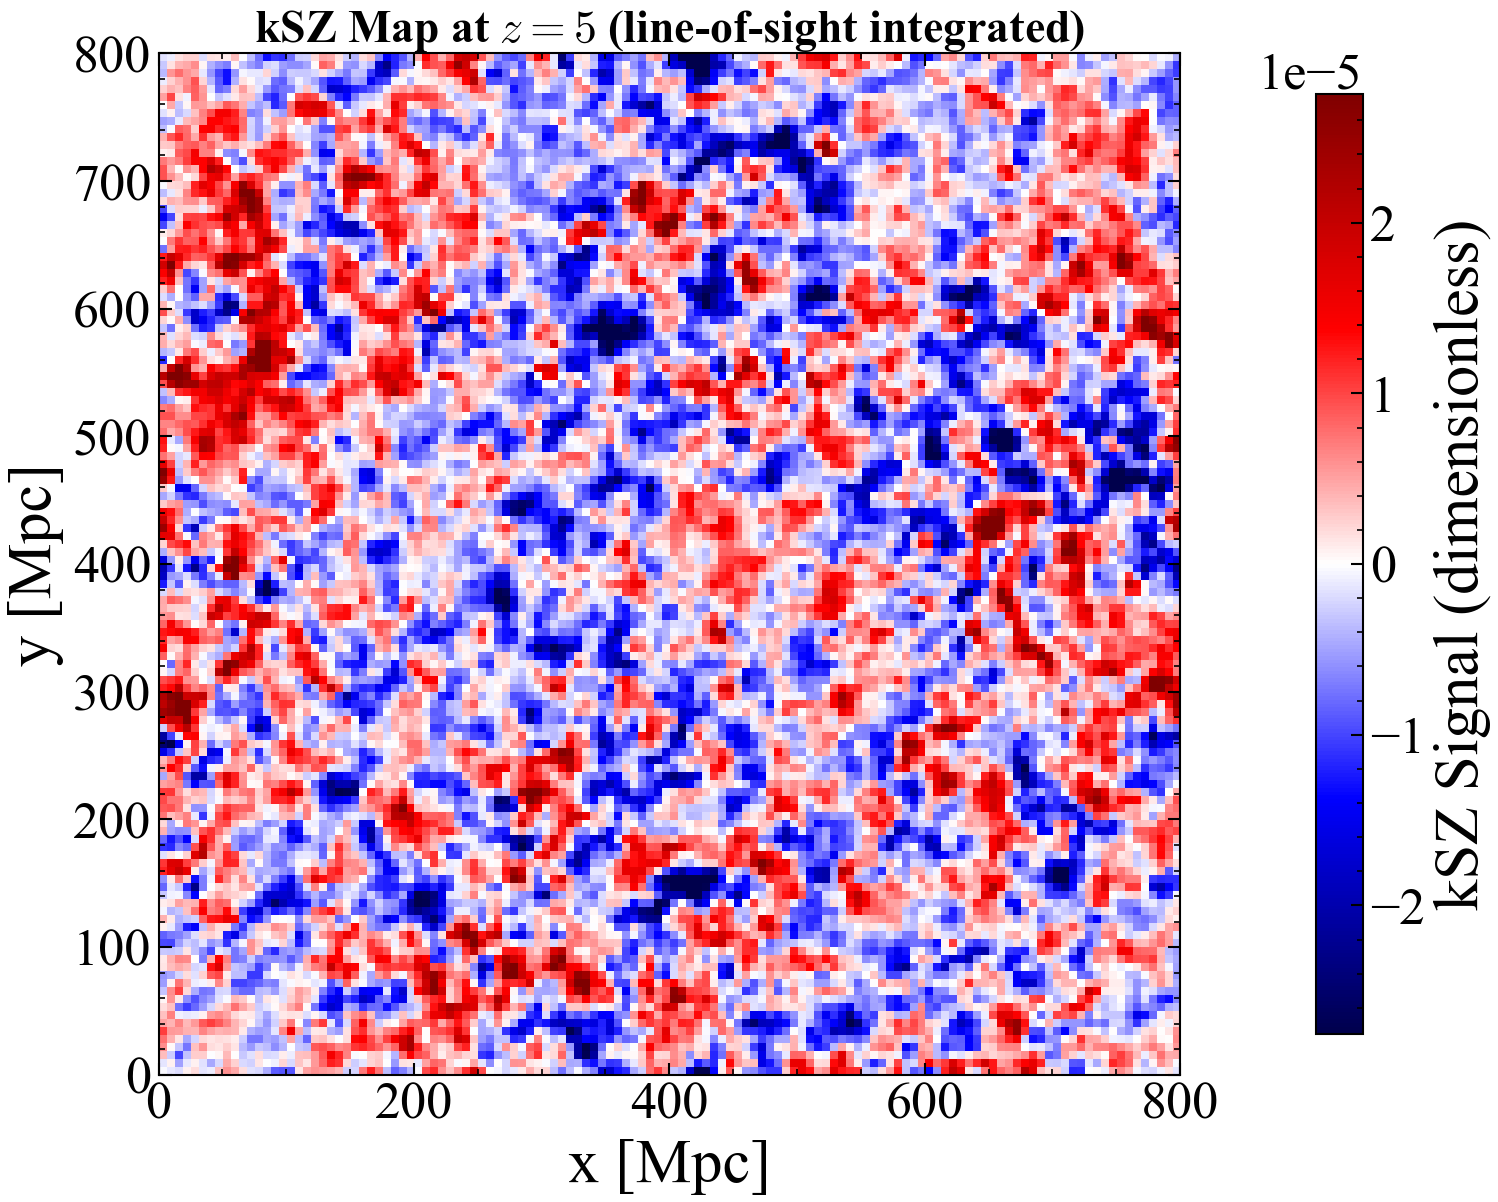

Saved: kSZ_map_histogram


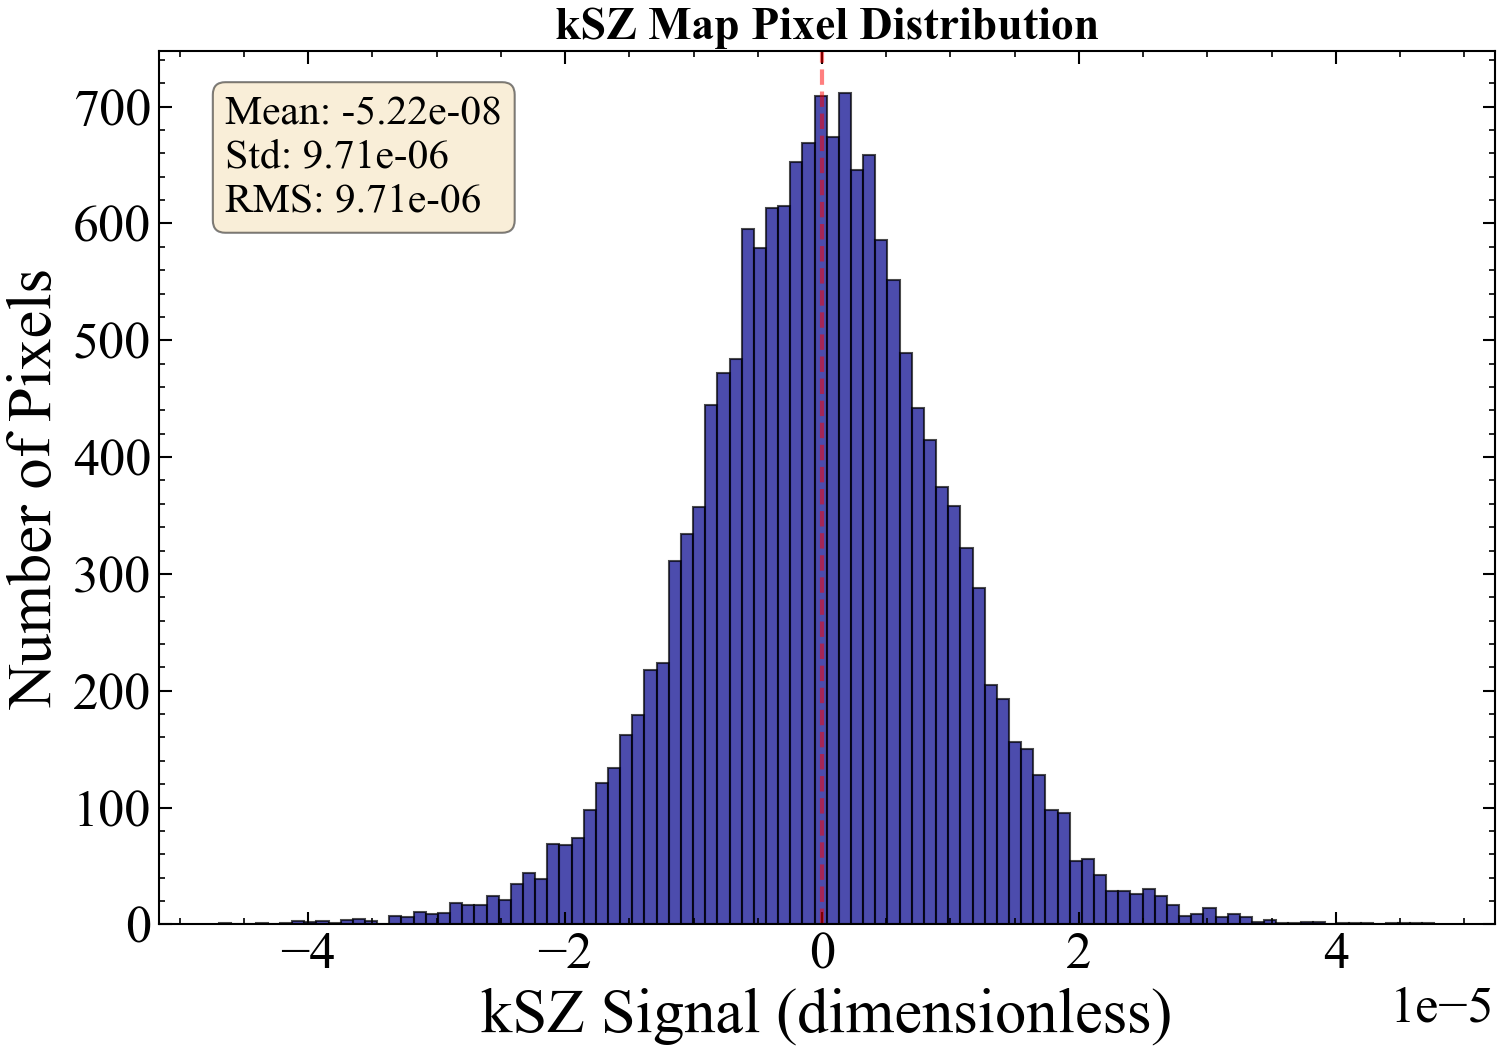


LINE-OF-SIGHT INTEGRATION COMPLETE
Result is DIMENSIONLESS (proper kSZ signal)
Integrated from z = 19.95 → 5.00
Map dimensions: 128 × 128 pixels
Physical size: 800.0 × 800.0 Mpc²
Pixel size: 6.25 Mpc
RMS kSZ signal: 9.7098e-06


In [68]:
# =============================================================================
# CELL 5: Compute Line-of-Sight Integrated kSZ Map (Dimensionless)
# kSZ(z=5) = ∫ n_e0 σ_T (1/a²) (1+δ) x_e v_z/c e^(-τ) ds
# Integration from z=20 to z=5 along line of sight
# =============================================================================

print(f"\n=== LINE-OF-SIGHT kSZ INTEGRATION ===")

# Physical constants in CGS
print(f"\n=== PHYSICAL CONSTANTS (CGS) ===")
c_cm_s = 3.0e10  # cm/s
sigma_T_cm2 = 6.6525e-25  # cm²
n_e0_cm3 = 2.06e-7  # cm⁻³
Mpc_to_cm = 3.0857e24  # cm/Mpc

print(f"c = {c_cm_s:.2e} cm/s")
print(f"σ_T = {sigma_T_cm2:.4e} cm²")
print(f"n_e0 = {n_e0_cm3:.4e} cm⁻³")
print(f"1 Mpc = {Mpc_to_cm:.4e} cm")

# Calculate dimensionless prefactor: n_e0 σ_T c
prefactor_cgs = n_e0_cm3 * sigma_T_cm2 * c_cm_s  # [1/s]
print(f"\nPrefactor n_e0 × σ_T × c = {prefactor_cgs:.4e} s⁻¹")

# Strip units from ds - convert to plain numpy array in Mpc
ds_Mpc = np.asarray(ds.value if hasattr(ds, 'value') else ds, dtype=float)
print(f"\n=== DISTANCE ELEMENTS ===")
print(f"ds (stripped units): {ds_Mpc.min():.6f} - {ds_Mpc.max():.6f} Mpc")

# Convert ds from Mpc to cm
ds_cm = ds_Mpc * Mpc_to_cm  # cm
print(f"ds in cm: {ds_cm.min():.4e} - {ds_cm.max():.4e} cm")

# =============================================================================
# Prepare integrand: (n_e0 σ_T c) × (1/a²) × kSZ_integrand × (ds/c)
# =============================================================================

# Scale factor a = 1/(1+z)
a = 1.0 / (1.0 + red_axis)  # Shape (964,)
a_squared = a**2

# Midpoint kSZ integrand (average between adjacent slices)
kSZ_integrand_mid = 0.5 * (kSZ_integrand_with_vis[:, :, :-1] + 
                            kSZ_integrand_with_vis[:, :, 1:])  # Shape (128, 128, 963)

# Midpoint a²
a_squared_mid = 0.5 * (a_squared[:-1] + a_squared[1:])  # Shape (963,)
a_squared_mid_3D = a_squared_mid[None, None, :]  # Shape (1, 1, 963)

# Full dimensionless integrand for kSZ:
# (n_e0 σ_T c) × (1/a²) × kSZ_integrand × (ds/c)
# [1/s] × [1] × [1] × [s] = [dimensionless]
kSZ_integrand_full = (prefactor_cgs / a_squared_mid_3D) * kSZ_integrand_mid * (ds_cm / c_cm_s)[None, None, :]

print(f"\nIntegrand shape: {kSZ_integrand_full.shape}")
print(f"Integrating over {kSZ_integrand_full.shape[2]} redshift slices")
print(f"From z = {red_axis.max():.2f} to z = {red_axis.min():.2f}")

# Check that integrand is dimensionless
print(f"Integrand type: {type(kSZ_integrand_full)}")
print(f"Sample integrand values: {kSZ_integrand_full[0, 0, :5]}")

# =============================================================================
# Integrate along line of sight (z-axis, axis=2)
# =============================================================================

kSZ_map = np.sum(kSZ_integrand_full, axis=2)  # Shape (128, 128), dimensionless

print(f"\n=== kSZ MAP STATISTICS (DIMENSIONLESS) ===")
print(f"Shape: {kSZ_map.shape}")
print(f"Type: {type(kSZ_map)}")
print(f"Mean: {kSZ_map.mean():.4e}")
print(f"Std:  {kSZ_map.std():.4e}")
print(f"Min:  {kSZ_map.min():.4e}")
print(f"Max:  {kSZ_map.max():.4e}")
print(f"RMS:  {np.sqrt(np.mean(kSZ_map**2)):.4e}")

# Add to lightcone object
lightcone.kSZ_map = kSZ_map

# =============================================================================
# PLOT: kSZ Map at z=5 (final observer slice)
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=True)

# Plot the kSZ map
im = ax.imshow(kSZ_map.T,  # Transpose for proper orientation
               cmap='seismic',
               origin='lower',
               extent=[0, user_params.BOX_LEN, 0, user_params.BOX_LEN],
               aspect='equal')

# Set symmetric color limits
vmax_map = np.percentile(np.abs(kSZ_map), 99)
im.set_clim(-vmax_map, vmax_map)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'kSZ Signal (dimensionless)', fontsize=30)
cbar.ax.tick_params(labelsize=25)

# Labels
ax.set_xlabel('x [Mpc]')
ax.set_ylabel('y [Mpc]')

# Save PDF without title
plot_name = "kSZ_map_z5"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Map at $z=5$ (line-of-sight integrated)"
)

print(f"Saved: {plot_name}")
plt.show()


# =============================================================================
# PLOT: Histogram of kSZ Map Values
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)

ax.hist(kSZ_map.flatten(), bins=100, color='darkblue', alpha=0.7, edgecolor='black')

ax.set_xlabel('kSZ Signal (dimensionless)')
ax.set_ylabel('Number of Pixels')
#ax.grid(True, alpha=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Zero')
#ax.legend(fontsize=14)

# Add statistics text
stats_text = f"Mean: {kSZ_map.mean():.2e}\nStd: {kSZ_map.std():.2e}\nRMS: {np.sqrt(np.mean(kSZ_map**2)):.2e}"
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=20,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Save PDF without title
plot_name = "kSZ_map_histogram"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title="kSZ Map Pixel Distribution"
)

print(f"Saved: {plot_name}")
plt.show()

# =============================================================================
# Summary
# =============================================================================

print(f"\n{'='*60}")
print(f"LINE-OF-SIGHT INTEGRATION COMPLETE")
print(f"{'='*60}")
print(f"Result is DIMENSIONLESS (proper kSZ signal)")
print(f"Integrated from z = {red_axis.max():.2f} → {red_axis.min():.2f}")
print(f"Map dimensions: {kSZ_map.shape[0]} × {kSZ_map.shape[1]} pixels")
print(f"Physical size: {user_params.BOX_LEN:.1f} × {user_params.BOX_LEN:.1f} Mpc²")
print(f"Pixel size: {user_params.BOX_LEN/kSZ_map.shape[0]:.2f} Mpc")
print(f"RMS kSZ signal: {np.sqrt(np.mean(kSZ_map**2)):.4e}")
print(f"{'='*60}")


COMPUTING kSZ POWER SPECTRUM

=== MAP PROPERTIES ===
Map size: 128 × 128 pixels
Physical size: 800.0 × 800.0 Mpc²
Pixel size: 6.250 Mpc/pixel
Map RMS: 9.7097e-06
Mean subtracted: 1.0588e-22

=== 2D POWER SPECTRUM ===
P(k) range: [8.8533e-43, 5.1617e-11] Mpc²

=== k-SPACE GRID ===
dk (fundamental): 0.007854 Mpc⁻¹
k range: [0.000000, 0.710861] Mpc⁻¹

=== AZIMUTHALLY AVERAGED P(k) ===
Valid k bins: 29 out of 34
P(k) range: [2.5848e-15, 1.2452e-11] Mpc²

=== CONVERSION TO ℓ SPACE ===
Reionization redshift: z = 5.0
Comoving distance: χ = 7800.0 Mpc
ℓ range: 98 to 6996
Saved: kSZ_Pk


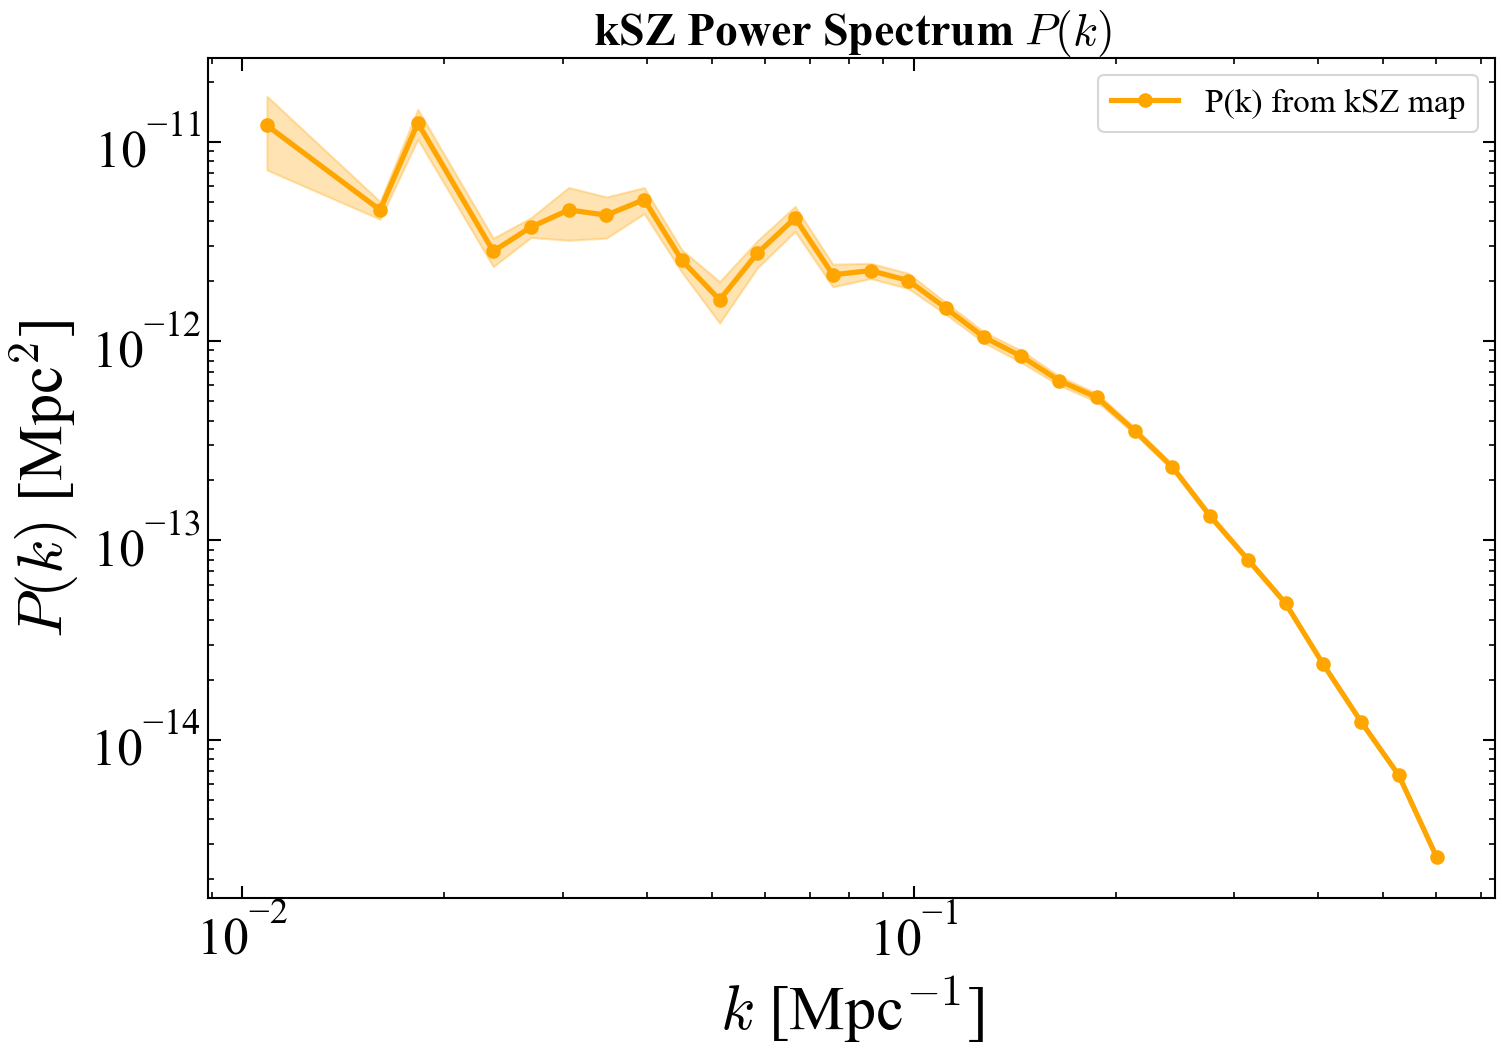

Saved: kSZ_Cl_corrected


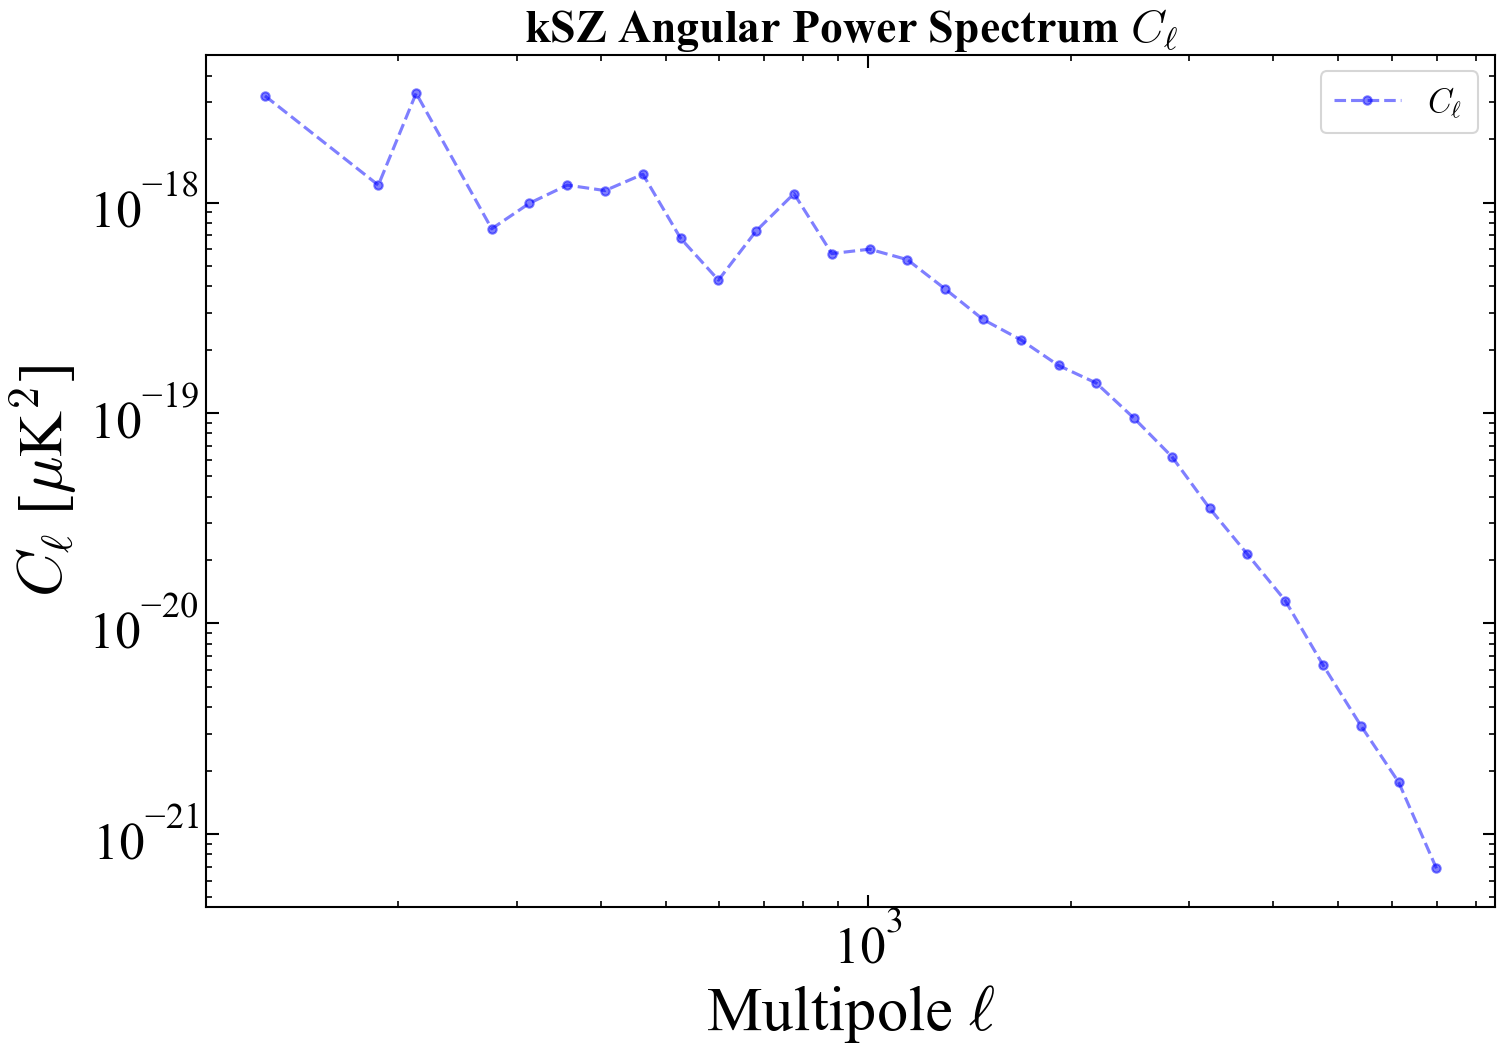

Saved: kSZ_Dl_corrected


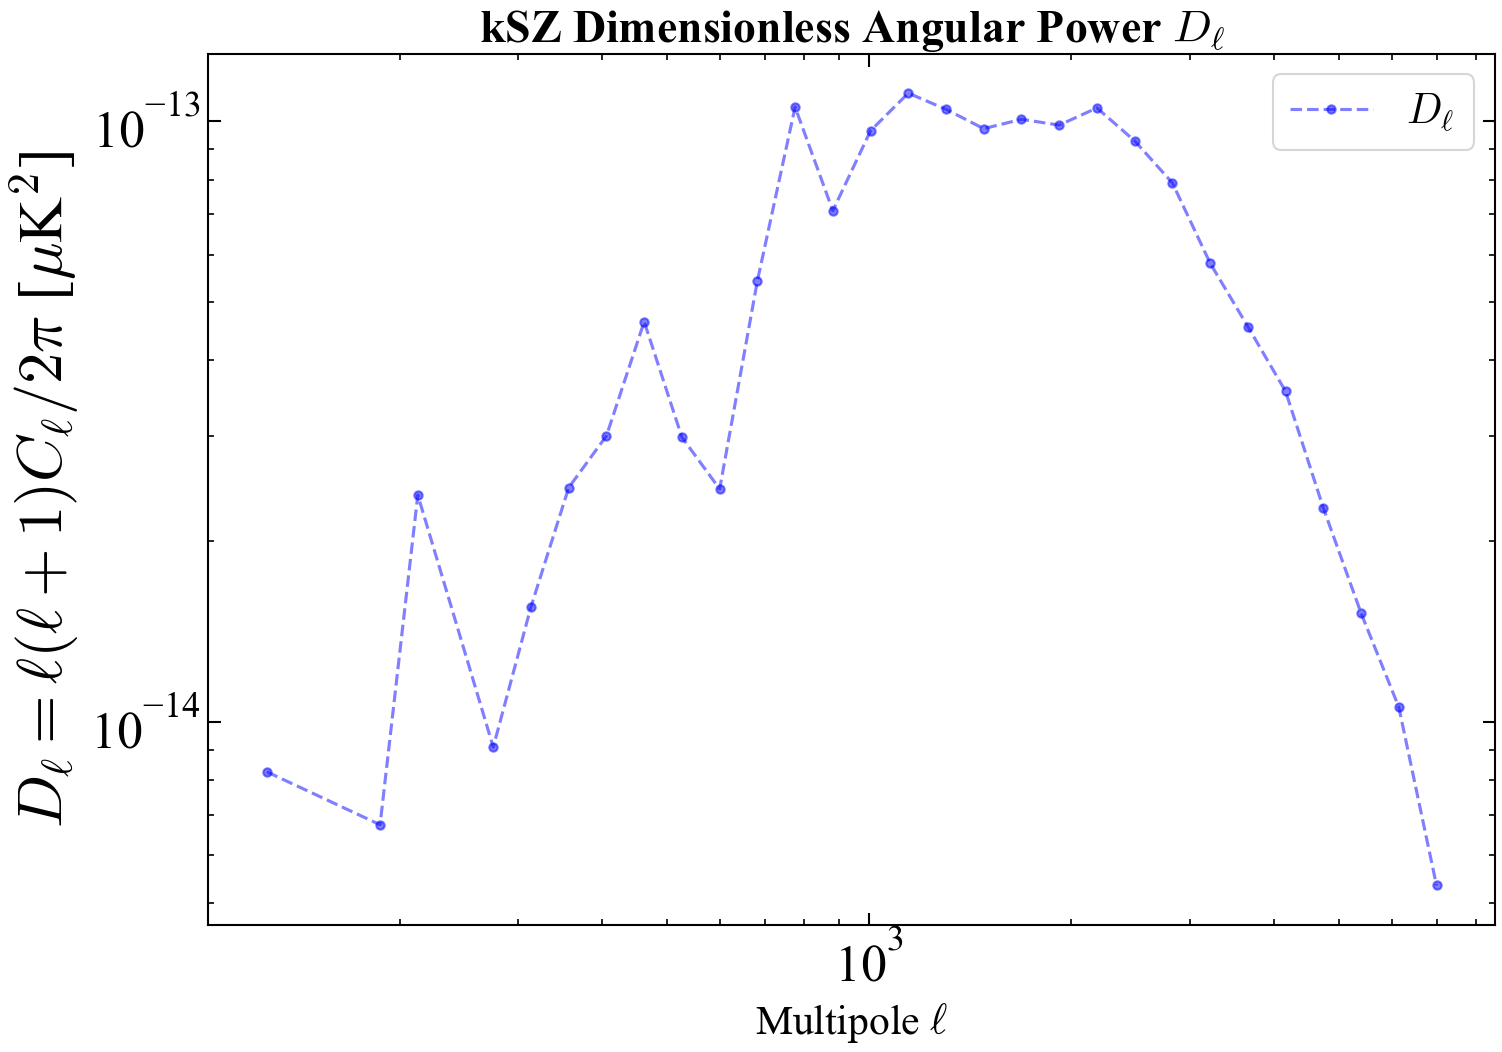


POWER SPECTRUM SUMMARY
P(k) computed in range: k = 0.0109 - 0.6009 Mpc⁻¹
C_ℓ computed in range: ℓ = 126.6 - 6996.1

NOTE: This uses flat-sky approximation


In [48]:
# =============================================================================
# CELL 6: Compute kSZ Power Spectrum - P(k), C_ℓ, and D_ℓ
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

print(f"\n{'='*60}")
print(f"COMPUTING kSZ POWER SPECTRUM")
print(f"{'='*60}")

# =============================================================================
# 1. Settings and Map Info
# =============================================================================

# Map info
npix_side = kSZ_map.shape[0]  # Should be 128
box_size_Mpc = user_params.BOX_LEN  # Physical size in Mpc
pix_size_Mpc = box_size_Mpc / npix_side  # Mpc per pixel

print(f"\n=== MAP PROPERTIES ===")
print(f"Map size: {npix_side} × {npix_side} pixels")
print(f"Physical size: {box_size_Mpc:.1f} × {box_size_Mpc:.1f} Mpc²")
print(f"Pixel size: {pix_size_Mpc:.3f} Mpc/pixel")
print(f"Map RMS: {np.std(kSZ_map):.4e}")

# Remove mean (important for power spectrum!)
kSZ_map_centered = kSZ_map - np.mean(kSZ_map)
print(f"Mean subtracted: {np.mean(kSZ_map_centered):.4e}")

# =============================================================================
# 2. Compute 2D Power Spectrum P(k) in [Mpc²]
# =============================================================================

# FFT and shift to center
fft_map = np.fft.fft2(kSZ_map_centered)
fft_map_shifted = np.fft.fftshift(fft_map)

# Pixel area in physical units
pix_area = pix_size_Mpc**2  # Mpc²

# 2D power spectrum: P(k) in [Mpc²]
ps2d = np.abs(fft_map_shifted)**2 * pix_area / (npix_side**4)

print(f"\n=== 2D POWER SPECTRUM ===")
print(f"P(k) range: [{ps2d.min():.4e}, {ps2d.max():.4e}] Mpc²")

# =============================================================================
# 3. k-space grid [Mpc⁻¹]
# =============================================================================

# Fundamental frequency
dk = 2 * np.pi / (npix_side * pix_size_Mpc)  # Mpc⁻¹

# k-space coordinates
kx = np.fft.fftshift(np.fft.fftfreq(npix_side)) * npix_side * dk
ky = np.fft.fftshift(np.fft.fftfreq(npix_side)) * npix_side * dk
kgrid = np.sqrt(kx[:, None]**2 + ky[None, :]**2)

print(f"\n=== k-SPACE GRID ===")
print(f"dk (fundamental): {dk:.6f} Mpc⁻¹")
print(f"k range: [{kgrid.min():.6f}, {kgrid.max():.6f}] Mpc⁻¹")

# =============================================================================
# 4. Azimuthally Averaged P(k)
# =============================================================================

# Define k bins (logarithmic spacing)
k_bins = np.logspace(np.log10(dk), np.log10(kgrid.max()*0.9), 35)
k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])
P1d = np.zeros(len(k_centers))
P1d_err = np.zeros(len(k_centers))

for i in range(len(k_centers)):
    mask = (kgrid >= k_bins[i]) & (kgrid < k_bins[i+1])
    if np.sum(mask) > 0:
        values = ps2d[mask]
        P1d[i] = np.mean(values)
        P1d_err[i] = np.std(values) / np.sqrt(np.sum(mask))
    else:
        P1d[i] = np.nan

print(f"\n=== AZIMUTHALLY AVERAGED P(k) ===")
valid_bins = np.sum(~np.isnan(P1d) & (P1d > 0))
print(f"Valid k bins: {valid_bins} out of {len(k_centers)}")
print(f"P(k) range: [{np.nanmin(P1d[P1d>0]):.4e}, {np.nanmax(P1d):.4e}] Mpc²")

# =============================================================================
# 5. Convert to ℓ space (flat-sky approximation for kSZ)
# =============================================================================

# For kSZ, we need the COMOVING distance to the reionization era
# At z=5, comoving distance (not angular diameter distance!)
z_reion = 5.0

# Comoving distance to z=5 in Planck cosmology: χ ≈ 7800 Mpc
chi_comoving_Mpc = 7800  # This is the light travel distance (comoving)

# Alternative: If you have angular diameter distance D_A
D_A_physical = 1300  # Physical angular diameter distance at z=5
chi_comoving_Mpc = D_A_physical * (1 + z_reion)  # = 1300 × 6 = 7800 Mpc

print(f"\n=== CONVERSION TO ℓ SPACE ===")
print(f"Reionization redshift: z = {z_reion}")
print(f"Comoving distance: χ = {chi_comoving_Mpc:.1f} Mpc")

# Flat-sky approximation: ℓ = k × χ
ell_from_k = k_centers * chi_comoving_Mpc/0.67

# Power spectrum conversion: C_ℓ = P(k) / χ²
Cl_kSZ_DA = P1d*0.67**2 / D_A_physical**2 
#Cl_kSZ_comov = P1d / chi_comoving_Mpc**2
# Convert to D_ℓ = ℓ(ℓ+1) C_ℓ / (2π) in μK²
Dl_kSZ_muK2_DA = ell_from_k * (ell_from_k + 1) * Cl_kSZ_DA / (2 * np.pi)
#Dl_kSZ_muK2_comov = ell_from_k * (ell_from_k + 1) * Cl_kSZ_comov / (2 * np.pi)

print(f"ℓ range: {ell_from_k.min():.0f} to {ell_from_k.max():.0f}")
#print(f"Peak D_ℓ: {Dl_kSZ_muK2.max():.2e} μK²")


# =============================================================================
# PLOT 1: P(k) - 3D Matter Power Spectrum
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)

valid = ~np.isnan(P1d) & (P1d > 0)
ax.loglog(k_centers[valid], P1d[valid], 'o-', color='orange', 
          linewidth=2.5, markersize=6, label='P(k) from kSZ map')
ax.fill_between(k_centers[valid], 
                (P1d - P1d_err)[valid], 
                (P1d + P1d_err)[valid], 
                alpha=0.3, color='orange')

ax.set_xlabel(r'$k$ [Mpc$^{-1}$]')
ax.set_ylabel(r'$P(k)$ [Mpc$^{2}$]')
#ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=16, loc='best')

# Save PDF without title
plot_name = "kSZ_Pk"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title="kSZ Power Spectrum $P(k)$"
)

print(f"Saved: {plot_name}")
plt.show()

# =============================================================================
# PLOT 2: C_ℓ - Angular Power Spectrum (CORRECTED)
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)

# Optionally compare with D_A version to see the difference
valid_DA = ~np.isnan(Cl_kSZ_DA) & (Cl_kSZ_DA > 0) & (ell_from_k > 10)
ax.loglog(ell_from_k[valid_DA], Cl_kSZ_DA[valid_DA], 'o--', 
          color='blue', alpha=0.5, linewidth=1.5, markersize=4,
          label=r'$C_\ell$ ')

ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$C_\ell$ [$\mu$K$^2$]')
ax.legend(fontsize=16, loc='best')

# Save PDF without title
plot_name = "kSZ_Cl_corrected"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Angular Power Spectrum $C_\ell$"
)

print(f"Saved: {plot_name}")
plt.show()



# =============================================================================
# PLOT 3: D_ℓ - Dimensionless Angular Power (CORRECTED)
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)



# Optionally compare with D_A version to see the difference
valid_DA = ~np.isnan(Dl_kSZ_muK2_DA) & (Dl_kSZ_muK2_DA > 0) & (ell_from_k > 10)
ax.loglog(ell_from_k[valid_DA], Dl_kSZ_muK2_DA[valid_DA], 'o--', 
          color='blue', alpha=0.5, linewidth=1.5, markersize=4,
          label=r'$D_\ell$ ')

ax.set_xlabel(r'Multipole $\ell$', fontsize=20)
ax.set_ylabel(r'$D_\ell = \ell(\ell+1)C_\ell / 2\pi$ [$\mu$K$^2$]')
ax.legend(loc='best')

plot_name = "kSZ_Dl_corrected"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Dimensionless Angular Power $D_\ell$"
)

print(f"Saved: {plot_name}")
plt.show()


# =============================================================================
# Summary
# =============================================================================

print(f"\n{'='*60}")
print(f"POWER SPECTRUM SUMMARY")
print(f"{'='*60}")
print(f"P(k) computed in range: k = {k_centers[valid].min():.4f} - {k_centers[valid].max():.4f} Mpc⁻¹")
print(f"C_ℓ computed in range: ℓ = {ell_from_k[valid].min():.1f} - {ell_from_k[valid].max():.1f}")
print(f"\nNOTE: This uses flat-sky approximation")
#print(f"Conversion: ℓ ≈ k × D_A where D_A = {D_A_Mpc:.1f} Mpc at z={z_obs}")
print(f"{'='*60}")


=== CMB TEMPERATURE ===
T_CMB(z=0) = 2.725 K
T_CMB(z=5) = 2.725 K = 2725000.00 μK

=== D_ℓ CONVERSION ===
Conversion factor: T_CMB²(z=5) = 7.4256e+12 μK²
Saved: kSZ_Dl_muK2


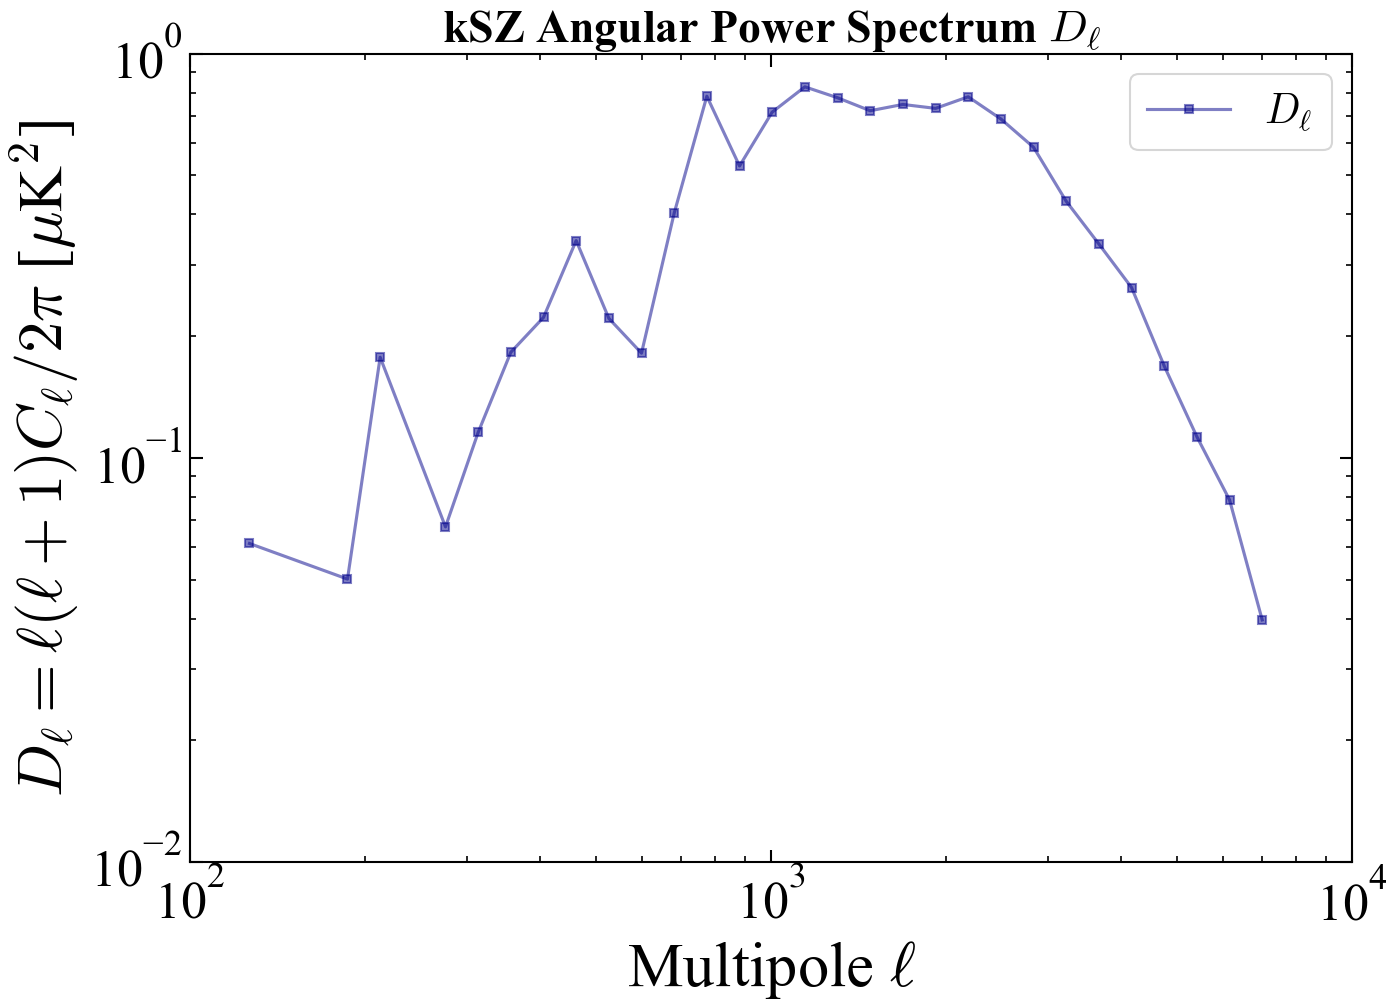

✓ Loaded Alvarez et al. (2016) data
Saved: kSZ_Dl_muK2_with_observations


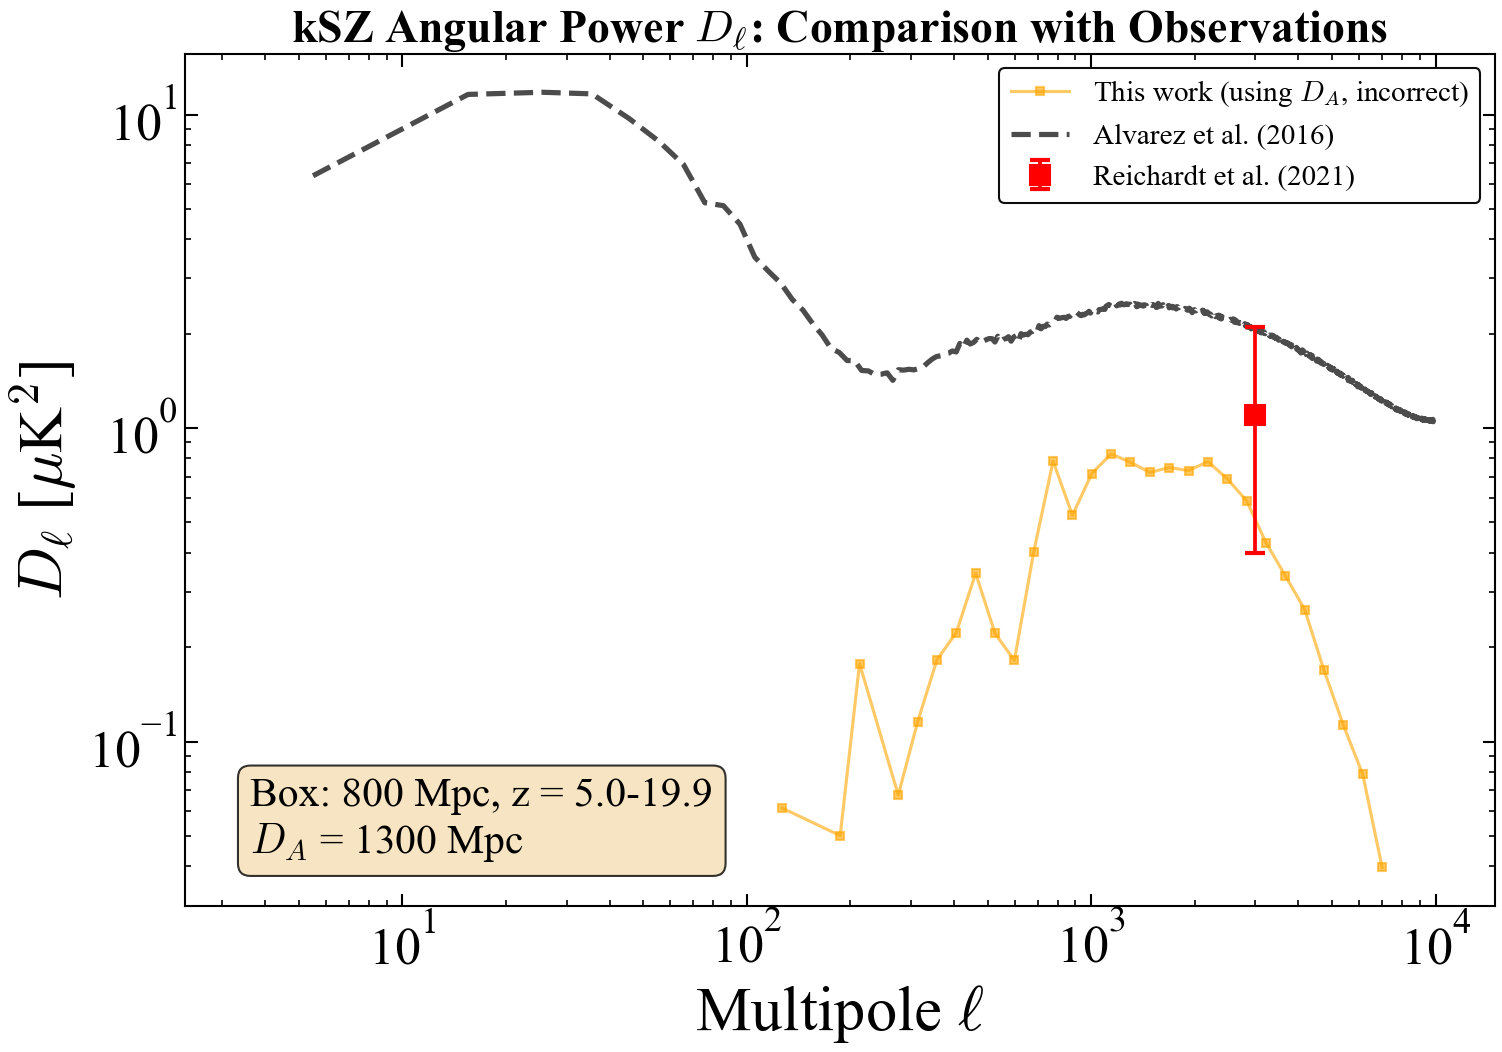


POWER SPECTRUM COMPARISON
This work:

Observations:
  Reichardt+2021 @ ℓ=3000: D_ℓ = 1.1 +1.0/-0.7 μK²

Models:
  Alvarez+2016: File loaded successfully


In [58]:
# =============================================================================
# 6. Convert D_ℓ to μK² using CMB temperature
# =============================================================================

# CMB temperature today
T_CMB_0_K = 2.725  # K

# CMB temperature at z=5
z_obs = 5.0
T_CMB_z5_K = T_CMB_0_K #* (1 + z_obs)  # K

# Convert to μK
T_CMB_z5_uK = T_CMB_z5_K * 1e6  # μK

print(f"\n=== CMB TEMPERATURE ===")
print(f"T_CMB(z=0) = {T_CMB_0_K:.3f} K")
print(f"T_CMB(z=5) = {T_CMB_z5_K:.3f} K = {T_CMB_z5_uK:.2f} μK")

# Convert D_ℓ from dimensionless to μK²
Dl_uK2_DA = Dl_kSZ_muK2_DA * T_CMB_z5_uK**2
Dl_uK2_comov = Dl_kSZ_muK2_comov * T_CMB_z5_uK**2

print(f"\n=== D_ℓ CONVERSION ===")
print(f"Conversion factor: T_CMB²(z=5) = {T_CMB_z5_uK**2:.4e} μK²")
#print(f"D_ℓ range: [{np.nanmin(Dl_uK2[Dl_uK2>0]):.4e}, {np.nanmax(Dl_uK2):.4e}] μK²")

#=============================================================================
# PLOT 3: D_ℓ - Angular Power Spectrum in μK²
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)

# version (physical D_A) for comparison
valid_DA = ~np.isnan(Dl_uK2_DA) & (Dl_uK2_DA > 0) & (ell_from_k > 10)
ax.loglog(ell_from_k[valid_DA], Dl_uK2_DA[valid_DA], 's-', 
          color='darkblue', alpha=0.5, linewidth=1.5, markersize=4,
          label=r'$D_\ell$ ')

from matplotlib.ticker import LogLocator, LogFormatterMathtext

# Force axis ranges to span multiple decades
ax.set_xlim(1e2, 1e4)
ax.set_ylim(1e-2, 1e0)

# X axis ticks
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=10))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=(2,3,4,5,6,7,8,9)))
ax.xaxis.set_major_formatter(LogFormatterMathtext())

# Y axis ticks
ax.yaxis.set_major_locator(LogLocator(base=10, numticks=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2,3,4,5,6,7,8,9)))
ax.yaxis.set_major_formatter(LogFormatterMathtext())


fig.set_constrained_layout(False)


ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$D_\ell = \ell(\ell+1)C_\ell / 2\pi$ [$\mu$K$^2$]')
ax.legend(loc='best')



# Save PDF without title
plot_name = "kSZ_Dl_muK2"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Angular Power Spectrum $D_\ell$"
)

print(f"Saved: {plot_name}")
plt.show()


# =============================================================================
# PLOT 4: D_ℓ in μK² - Physical Units WITH OBSERVATIONS
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)

# INCORRECT version (physical D_A) - shown for comparison
valid_DA = ~np.isnan(Dl_uK2_DA) & (Dl_uK2_DA > 0) & (ell_from_k > 10)
ax.loglog(ell_from_k[valid_DA], Dl_uK2_DA[valid_DA], 's-', 
          color='orange', alpha=0.6, linewidth=1.5, markersize=4,
          label='This work (using $D_A$, incorrect)', zorder=5)

# =============================================================================
# Add Alvarez et al. (2016) model
# =============================================================================
try:
    alvarez_file = "Alvarez2016_binned_smoothed.txt"
    fullsky_data = np.loadtxt(alvarez_file)
    ells_fullsky = fullsky_data[:, 0]
    Dell_fullsky = fullsky_data[:, 1]
    
    ax.loglog(ells_fullsky, Dell_fullsky, lw=2.5, ls='--', 
              color='black', label='Alvarez et al. (2016)', 
              alpha=0.7, zorder=5)
    print("✓ Loaded Alvarez et al. (2016) data")
except FileNotFoundError:
    print("⚠ Warning: Alvarez data file not found at expected location")
    print("  Tried:", alvarez_file)

# =============================================================================
# Add Reichardt et al. (2021) measurement
# =============================================================================
ell_reichardt = 3000
D_reichardt = 1.1  # μK²
D_reichardt_err_upper = 1.0
D_reichardt_err_lower = 0.7

ax.errorbar(ell_reichardt, D_reichardt, 
            yerr=[[D_reichardt_err_lower], [D_reichardt_err_upper]],
            fmt='s', markersize=10, capsize=5, capthick=2, 
            color='red', label='Reichardt et al. (2021)', 
            zorder=15)

# =============================================================================
# Formatting
# =============================================================================
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$D_\ell$ [$\mu$K$^2$]')
#ax.set_xlim(10, 10000)
#ax.set_ylim(1e-2, 1e10)  # Adjust based on your data
#ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='best', fontsize=14, frameon=True, framealpha=0.95, 
          edgecolor='black')

# Add info text
info_text = (f"Box: {user_params.BOX_LEN:.0f} Mpc, "
             f"z = {red_axis.min():.1f}-{red_axis.max():.1f}\n"
             f"$D_A$ = {D_A_physical:.0f} Mpc")
ax.text(0.05, 0.05, info_text, transform=ax.transAxes, 
        fontsize=20, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Save PDF without title
plot_name = "kSZ_Dl_muK2_with_observations"

save_pdf_png(
    fig,
    ax,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Angular Power $D_\ell$: Comparison with Observations"
)

print(f"Saved: {plot_name}")
plt.show()

# =============================================================================
# Summary with Comparison
# =============================================================================
print(f"\n{'='*60}")
print(f"POWER SPECTRUM COMPARISON")
print(f"{'='*60}")
print(f"This work:")
#print(f"  D_ℓ(μK²) range: {np.nanmin(Dl_uK2[Dl_uK2>0]):.4e} - {np.nanmax(Dl_uK2):.4e}")
print(f"\nObservations:")
print(f"  Reichardt+2021 @ ℓ=3000: D_ℓ = {D_reichardt:.1f} +{D_reichardt_err_upper:.1f}/-{D_reichardt_err_lower:.1f} μK²")
print(f"\nModels:")
print(f"  Alvarez+2016: File loaded successfully" if 'ells_fullsky' in locals() else "  Alvarez+2016: File not found")
print(f"{'='*60}")

In [40]:
import pandas as pd

# Save the CORRECT version (comoving distance)
df_comov = pd.DataFrame({
    'ell': ell_from_k[valid_comov],
    'Dl_muK2': Dl_uK2_comov[valid_comov]
})
df_comov.to_csv('ksz_power_spectrum_comoving.csv', index=False)
print(f"Saved {len(df_comov)} data points to ksz_power_spectrum_comoving.csv")

# Save the INCORRECT version (physical D_A) for comparison
df_DA = pd.DataFrame({
    'ell': ell_from_k[valid_DA],
    'Dl_muK2': Dl_uK2_DA[valid_DA]
})
df_DA.to_csv('ksz_power_spectrum_DA.csv', index=False)
print(f"Saved {len(df_DA)} data points to ksz_power_spectrum_DA.csv")

# Or save both in one file with different columns
df_both = pd.DataFrame({
    'ell': ell_from_k[valid_comov],
    'Dl_muK2_comoving': Dl_uK2_comov[valid_comov],
    'Dl_muK2_DA': Dl_uK2_DA[valid_comov]  # Using same ell values
})
df_both.to_csv('ksz_power_spectrum_comparison.csv', index=False)
print(f"Saved comparison with {len(df_both)} data points to ksz_power_spectrum_comparison.csv")

Saved 29 data points to ksz_power_spectrum_comoving.csv
Saved 29 data points to ksz_power_spectrum_DA.csv
Saved comparison with 29 data points to ksz_power_spectrum_comparison.csv
